# Experiment 8: Clustering Human Activity Recognition Data using K-Means, DBSCAN, and Hierarchical Clustering

**Course:** ICS1512 – Machine Learning Algorithms Laboratory  |  **Programme:** M.Tech (Integrated) CSE, Semester V  |  **Academic Year:** 2025–2026 (Odd)
**Student:** Sharruk S  |  **Register Number:** 3122247001061
**Institution:** Sri Sivasubramaniya Nadar College of Engineering, Chennai

## Objective

To implement and analyse three clustering algorithms on the **UCI Human Activity Recognition (HAR) Using Smartphones** dataset:

* **Model A** – K-Means clustering (with elbow and silhouette analysis to choose *k*)
* **Model B** – DBSCAN (with systematic tuning of `eps` and `min_samples`)
* **Model C** – Hierarchical Agglomerative Clustering (single, complete, average and Ward linkage; dendrograms)

The clusters are visualised in 2-D (PCA, and t-SNE as a supplementary view), evaluated with three **internal** metrics (Silhouette, Davies–Bouldin, Calinski–Harabasz) and two **external** metrics (Adjusted Rand Index, Normalized Mutual Information), and compared with the six known activities.

## Ground rules followed in this notebook

1. The ground-truth activity labels are **never** given to any clustering algorithm. They are used only for ARI, NMI, contingency tables and interpretation.
2. The final *k* for K-Means and the "best" DBSCAN configuration are selected using **internal criteria only** (no label information), so model selection is not contaminated by the labels.
3. Every number quoted in the observations and in the PDF report is produced by a cell in this notebook. No value is estimated or typed in by hand.
4. All randomised steps use `random_state = 42`.

## 1. Imports, Configuration and Plot Style

Plot style follows the laboratory formatting used in Experiment 7 (15 pt serif fonts, bold axis labels). Liberation Serif is used as a metric-compatible substitute for Times New Roman when the latter is not installed.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, sys, gc, json, time, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
import scipy
import sklearn
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors, sort_graph_by_row_values
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score)

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram, cophenet

def safe_dendrogram(*args, **kwargs):
    """scipy's dendrogram() recurses once per merge on the path from the root, so for ~10,000
    observations it can exceed Python's default recursion limit -- especially inside Jupyter, where
    the kernel's own call stack already uses part of that budget. Running it in a dedicated thread
    with a large C stack and a raised Python recursion limit avoids this regardless of context."""
    import threading
    result, error = {}, {}
    def _run():
        old_limit = sys.getrecursionlimit()
        sys.setrecursionlimit(1_000_000)
        try:
            result["value"] = dendrogram(*args, **kwargs)
        except Exception as e:
            error["value"] = e
        finally:
            sys.setrecursionlimit(old_limit)
    threading.stack_size(512 * 1024 * 1024)
    t = threading.Thread(target=_run)
    t.start(); t.join()
    if "value" in error:
        raise error["value"]
    return result["value"]

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def _cpu_model():
    try:
        with open("/proc/cpuinfo") as f:
            for line in f:
                if line.startswith("model name"):
                    return line.split(":", 1)[1].strip()
    except Exception:
        pass
    return platform.processor() or "unknown"

def _mem_gb():
    try:
        with open("/proc/meminfo") as f:
            return round(int(f.readline().split()[1]) / 1024 / 1024, 1)
    except Exception:
        return None

ENV = {
    "python": platform.python_version(),
    "sklearn": sklearn.__version__,
    "scipy": scipy.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__,
    "os": platform.platform(),
    "cpu": _cpu_model(),
    "logical_cpus": os.cpu_count(),
    "ram_gb": _mem_gb(),
}
for k_, v_ in ENV.items():
    print(f"{k_:14s}: {v_}")

import ctypes
def free_memory():
    """Release Python garbage and return freed heap pages to the OS (keeps peak memory low on small machines)."""
    gc.collect()
    try:
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass

def rss_mb():
    try:
        with open("/proc/self/status") as f:
            for line in f:
                if line.startswith("VmRSS"):
                    return int(line.split()[1]) / 1024
    except Exception:
        return float("nan")

# Container for every number that is later quoted in the report (written to tables/results.json at the end)
RESULTS = {"env": ENV, "random_state": RANDOM_STATE}

python        : 3.12.3
sklearn       : 1.8.0
scipy         : 1.17.1
numpy         : 2.4.4
pandas        : 3.0.2
matplotlib    : 3.10.8
seaborn       : 0.13.2
os            : Linux-6.18.44-fc-v37-x86_64-with-glibc2.39
cpu           : Intel(R) Xeon(R) Processor @ 2.10GHz
logical_cpus  : 1
ram_gb        : 3.9


In [2]:
FONT_FAMILY = "Liberation Serif"
if FONT_FAMILY not in {f.name for f in font_manager.fontManager.ttflist}:
    FONT_FAMILY = "DejaVu Serif"
    print("Liberation Serif not found - falling back to DejaVu Serif.")
else:
    print(f"Using '{FONT_FAMILY}' as a metric-compatible substitute for Times New Roman.")
RESULTS["plot_font"] = FONT_FAMILY

plt.rcParams.update({
    "font.family": FONT_FAMILY, "font.size": 15,
    "axes.titlesize": 15, "axes.labelsize": 15, "axes.labelweight": "bold",
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "legend.fontsize": 15, "figure.titlesize": 15,
})

FIG_DIR, TAB_DIR = "figures", "tables"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

def save_fig(fig, name):
    """Save a figure as EPS (600 DPI, vector) and PNG (300 DPI, used in the PDF report)."""
    fig.savefig(f"{FIG_DIR}/{name}.eps", format="eps", dpi=600, bbox_inches="tight")
    fig.savefig(f"{FIG_DIR}/{name}.png", format="png", dpi=300, bbox_inches="tight")
    print(f"Saved {FIG_DIR}/{name}.eps and .png")

def save_table(df, name):
    """Save a table as CSV (full precision). The report reads these CSVs directly."""
    df.to_csv(f"{TAB_DIR}/{name}.csv", index=False)
    print(f"Saved {TAB_DIR}/{name}.csv  ({len(df)} rows)")

Using 'Liberation Serif' as a metric-compatible substitute for Times New Roman.


## 2. Dataset Path Resolution and Verification

The notebook lives in `assign8/`, so the dataset is expected at `../datasets/UCI HAR Dataset`. Rather than trusting that path, the cell below searches several candidate locations (including every parent folder of the working directory) and accepts a folder **only if all required files exist**. Nothing is loaded before this check passes.

In [3]:
REQUIRED_FILES = [
    "README.txt", "activity_labels.txt", "features.txt", "features_info.txt",
    "train/X_train.txt", "train/y_train.txt", "train/subject_train.txt",
    "test/X_test.txt", "test/y_test.txt", "test/subject_test.txt",
]

def find_har_dir():
    here = Path.cwd().resolve()
    candidates = [Path("../datasets/UCI HAR Dataset"), Path("datasets/UCI HAR Dataset"), Path("UCI HAR Dataset")]
    candidates += [p / "datasets" / "UCI HAR Dataset" for p in [here, *here.parents][:6]]
    tried = []
    for c in candidates:
        ok = c.is_dir() and all((c / f).is_file() for f in REQUIRED_FILES)
        tried.append((str(c), ok))
        if ok:
            return c.resolve(), tried
    raise FileNotFoundError("UCI HAR Dataset not found (or incomplete). Paths tried:\n" +
                            "\n".join(f"  {p}  -> {'OK' if o else 'missing/incomplete'}" for p, o in tried))

HAR_DIR, _tried = find_har_dir()
print("Working directory :", Path.cwd().resolve())
print("Dataset folder    :", HAR_DIR)
print("\nRequired-file check:")
for f in REQUIRED_FILES:
    p = HAR_DIR / f
    print(f"  [{'OK' if p.is_file() else 'MISSING'}] {f}  ({p.stat().st_size/1e6:.2f} MB)")
print("\nInertial Signals folders present:",
      (HAR_DIR / "train" / "Inertial Signals").is_dir(), (HAR_DIR / "test" / "Inertial Signals").is_dir(),
      "(not used - the 561 pre-extracted features are used, as specified)")

Working directory : /home/claude/repo/assign8
Dataset folder    : /home/claude/repo/datasets/UCI HAR Dataset

Required-file check:
  [OK] README.txt  (0.01 MB)
  [OK] activity_labels.txt  (0.00 MB)
  [OK] features.txt  (0.02 MB)
  [OK] features_info.txt  (0.00 MB)
  [OK] train/X_train.txt  (66.01 MB)
  [OK] train/y_train.txt  (0.01 MB)
  [OK] train/subject_train.txt  (0.02 MB)
  [OK] test/X_test.txt  (26.46 MB)
  [OK] test/y_test.txt  (0.01 MB)
  [OK] test/subject_test.txt  (0.01 MB)

Inertial Signals folders present: True True (not used - the 561 pre-extracted features are used, as specified)


## 3. Data Loading

All eight required files are loaded: `features.txt` (feature names), `activity_labels.txt`, and the `X`, `y`, `subject` files of the train and test partitions. Feature names come from `features.txt`. The original UCI split (train 7,352 / test 2,947) is **not needed for unsupervised clustering**, so both partitions are concatenated into one dataset of all observations; a `split` column keeps the origin for reference.

In [4]:
def read_ws(path, **kw):
    return pd.read_csv(path, sep=r"\s+", header=None, engine="c", **kw)

features = read_ws(HAR_DIR / "features.txt", names=["idx", "name"])
activity_labels = read_ws(HAR_DIR / "activity_labels.txt", names=["id", "name"])

n_dup_names = int(features["name"].duplicated(keep=False).sum())
print(f"features.txt: {len(features)} features; {n_dup_names} rows share a name with another feature "
      f"({features['name'][features['name'].duplicated()].nunique()} distinct duplicated names)")
# Some HAR feature names are repeated (e.g. fBodyAcc-bandsEnergy() blocks). Make column names unique by
# appending the original 1-based feature index ONLY to the repeated names, so no column is dropped or merged.
dup_mask = features["name"].duplicated(keep=False)
feature_names = np.where(dup_mask, features["name"] + "__" + features["idx"].astype(str), features["name"]).tolist()
assert len(set(feature_names)) == len(feature_names) == 561

X_train = read_ws(HAR_DIR / "train" / "X_train.txt"); X_train.columns = feature_names
X_test  = read_ws(HAR_DIR / "test" / "X_test.txt");   X_test.columns = feature_names
y_train = read_ws(HAR_DIR / "train" / "y_train.txt")[0].to_numpy()
y_test  = read_ws(HAR_DIR / "test" / "y_test.txt")[0].to_numpy()
s_train = read_ws(HAR_DIR / "train" / "subject_train.txt")[0].to_numpy()
s_test  = read_ws(HAR_DIR / "test" / "subject_test.txt")[0].to_numpy()

assert len(X_train) == len(y_train) == len(s_train) and len(X_test) == len(y_test) == len(s_test)

act_map = dict(zip(activity_labels["id"], activity_labels["name"]))
print("\nActivity labels (activity_labels.txt):", act_map)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape, "| subject_train:", s_train.shape, "| subject_test:", s_test.shape)

# Combine train + test
X_df = pd.concat([X_train, X_test], ignore_index=True)
meta = pd.DataFrame({
    "subject": np.concatenate([s_train, s_test]),
    "activity_id": np.concatenate([y_train, y_test]),
    "split": ["train"] * len(X_train) + ["test"] * len(X_test),
})
meta["activity"] = meta["activity_id"].map(act_map)
N, P = X_df.shape
print(f"\nCombined dataset: {N} observations x {P} features")

features.txt: 561 features; 126 rows share a name with another feature (42 distinct duplicated names)



Activity labels (activity_labels.txt): {1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}
X_train: (7352, 561) | X_test: (2947, 561)
y_train: (7352,) | y_test: (2947,) | subject_train: (7352,) | subject_test: (2947,)

Combined dataset: 10299 observations x 561 features


## 4. Preprocessing

Steps: (i) data-quality checks (dimensions, dtypes, missing values, duplicate observations), (ii) encoding of the categorical activity labels, (iii) standardisation of all 561 numeric features. The label encoding is created **only for evaluation and plotting**.

### 4.1 Data-quality checks

In [5]:
print("=== Data-quality report (values used in the PDF report) ===")
print("Dimensions (rows, features)     :", X_df.shape)
print("Feature dtypes                  :", dict(X_df.dtypes.value_counts().astype(int).rename(str)))
print("Total missing values (features) :", int(X_df.isna().sum().sum()))
print("Missing values (labels/subjects):", int(meta.isna().sum().sum()))
n_dup_rows = int(X_df.duplicated().sum())
print("Duplicate observations          :", n_dup_rows)
print("Feature value range (min, max)  :", (float(X_df.to_numpy().min()), float(X_df.to_numpy().max())))
print("Number of subjects              :", meta["subject"].nunique())
print("Train / Test rows               :", int((meta['split']=='train').sum()), "/", int((meta['split']=='test').sum()))
print("Number of activity classes      :", meta["activity_id"].nunique())

RESULTS["dataset"] = {
    "n_samples": int(N), "n_features": int(P),
    "n_missing_features": int(X_df.isna().sum().sum()),
    "n_duplicate_rows": n_dup_rows,
    "n_train": int((meta["split"] == "train").sum()), "n_test": int((meta["split"] == "test").sum()),
    "n_subjects": int(meta["subject"].nunique()), "n_classes": int(meta["activity_id"].nunique()),
    "value_min": float(X_df.to_numpy().min()), "value_max": float(X_df.to_numpy().max()),
    "n_duplicated_feature_names": n_dup_names,
    "dtype_counts": {str(k): int(v) for k, v in X_df.dtypes.value_counts().items()},
}

=== Data-quality report (values used in the PDF report) ===
Dimensions (rows, features)     : (10299, 561)
Feature dtypes                  : {'float64': np.int64(561)}
Total missing values (features) : 0
Missing values (labels/subjects): 0


Duplicate observations          : 0
Feature value range (min, max)  : (-1.0, 1.0)
Number of subjects              : 30
Train / Test rows               : 7352 / 2947
Number of activity classes      : 6


### 4.2 Label encoding

Activity ids 1–6 from `activity_labels.txt` are mapped to names for reporting and to integer codes 0–5 (`y_true`) for the external metrics. `y_true` is **not** an input to any clustering algorithm.

In [6]:
ACT_IDS = sorted(act_map)
ACT_NAMES = [act_map[i] for i in ACT_IDS]
y_true = (meta["activity_id"].to_numpy() - 1).astype(int)
enc_table = pd.DataFrame({"activity_id": ACT_IDS, "activity": ACT_NAMES, "integer_code_y_true": [i - 1 for i in ACT_IDS]})
display(enc_table)

ACT_COLORS = dict(zip(ACT_NAMES, ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]))

,activity_id,activity,integer_code_y_true
0,1,WALKING,0
1,2,WALKING_UPSTAIRS,1
2,3,WALKING_DOWNSTAIRS,2
3,4,SITTING,3
4,5,STANDING,4
5,6,LAYING,5


### 4.3 Standardisation

`StandardScaler` rescales each feature to zero mean and unit variance: $z = (x-\mu)/\sigma$. K-Means, DBSCAN and Ward/complete/average linkage all rely on **Euclidean distance**, so features with larger variance would dominate the distance and the clustering would reflect feature scale rather than structure. The HAR features are already provided within $[-1, 1]$, but the check in §5 shows their standard deviations still differ by a large factor, so standardisation is applied. The scaler is fit on all observations; this is unsupervised and uses no labels, so there is no label leakage.

In [7]:
scaler = StandardScaler()
X_raw = X_df.to_numpy(dtype=np.float64)
X_scaled = scaler.fit_transform(X_raw)

raw_std = X_raw.std(axis=0)
print("Before scaling - per-feature std: min = %.4f, max = %.4f, max/min ratio = %.1f" % (raw_std.min(), raw_std.max(), raw_std.max() / raw_std.min()))
print("After scaling  - per-feature mean: max |mean| = %.2e ; std: min = %.4f, max = %.4f" % (np.abs(X_scaled.mean(0)).max(), X_scaled.std(0).min(), X_scaled.std(0).max()))
print("Zero-variance features:", int((raw_std == 0).sum()))
print("X_scaled shape:", X_scaled.shape, "| any NaN:", bool(np.isnan(X_scaled).any()))

RESULTS["scaling"] = {"raw_std_min": float(raw_std.min()), "raw_std_max": float(raw_std.max()),
                      "raw_std_ratio": float(raw_std.max() / raw_std.min()),
                      "max_abs_mean_after": float(np.abs(X_scaled.mean(0)).max()),
                      "std_after_min": float(X_scaled.std(0).min()), "std_after_max": float(X_scaled.std(0).max()),
                      "n_zero_variance": int((raw_std == 0).sum())}

Before scaling - per-feature std: min = 0.0371, max = 0.7494, max/min ratio = 20.2


After scaling  - per-feature mean: max |mean| = 2.60e-15 ; std: min = 1.0000, max = 1.0000
Zero-variance features: 0
X_scaled shape: (10299, 561) | any NaN: False


## 5. Exploratory Data Analysis

### 5.1 Activity distribution

,Activity,Count,Percent,Train,Test
0,WALKING,1722,16.72,1226,496
1,WALKING_UPSTAIRS,1544,14.99,1073,471
2,WALKING_DOWNSTAIRS,1406,13.65,986,420
3,SITTING,1777,17.25,1286,491
4,STANDING,1906,18.51,1374,532
5,LAYING,1944,18.88,1407,537


Saved tables/table_activity_distribution.csv  (6 rows)
Class balance: largest/smallest class ratio = 1.383


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig01_activity_distribution.eps and .png


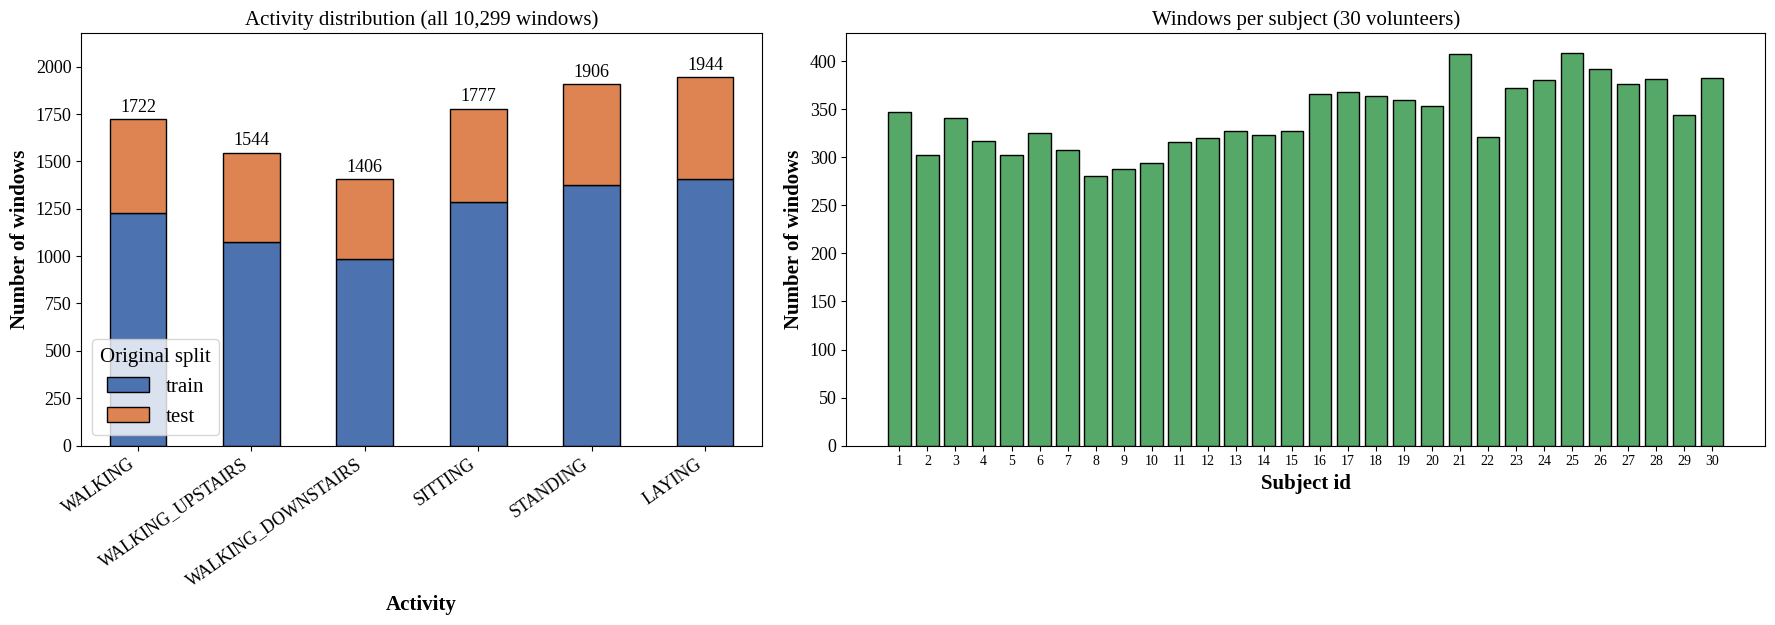

In [8]:
act_counts = meta["activity"].value_counts().reindex(ACT_NAMES)
act_table = pd.DataFrame({"Activity": ACT_NAMES, "Count": act_counts.values, "Percent": (100 * act_counts / N).round(2).values})
act_table["Train"] = [int(((meta.activity == a) & (meta.split == "train")).sum()) for a in ACT_NAMES]
act_table["Test"] = [int(((meta.activity == a) & (meta.split == "test")).sum()) for a in ACT_NAMES]
display(act_table)
save_table(act_table, "table_activity_distribution")
print("Class balance: largest/smallest class ratio = %.3f" % (act_counts.max() / act_counts.min()))
RESULTS["activity_counts"] = {a: int(c) for a, c in act_counts.items()}
RESULTS["activity_balance_ratio"] = float(act_counts.max() / act_counts.min())

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5), gridspec_kw={"width_ratios": [1, 1.35]})
cs = pd.crosstab(meta["activity"], meta["split"]).reindex(ACT_NAMES)[["train", "test"]]
cs.plot(kind="bar", stacked=True, ax=axes[0], color=["#4C72B0", "#DD8452"], edgecolor="black")
for i, tot in enumerate(cs.sum(axis=1)):
    axes[0].text(i, tot + 40, f"{tot}", ha="center", fontsize=13)
axes[0].set_title("Activity distribution (all 10,299 windows)")
axes[0].set_xlabel("Activity"); axes[0].set_ylabel("Number of windows")
axes[0].set_xticklabels(ACT_NAMES, rotation=35, ha="right"); axes[0].set_ylim(0, cs.sum(axis=1).max() * 1.12)
axes[0].legend(title="Original split")
sc = meta["subject"].value_counts().sort_index()
axes[1].bar(sc.index.astype(str), sc.values, color="#55A868", edgecolor="black")
axes[1].set_title("Windows per subject (30 volunteers)")
axes[1].set_xlabel("Subject id"); axes[1].set_ylabel("Number of windows")
axes[1].tick_params(axis="x", labelsize=10)
plt.tight_layout()
save_fig(fig, "fig01_activity_distribution")
plt.show()

### 5.2 Descriptive statistics

The full descriptive-statistics table (count, mean, std, min, quartiles, max for all 561 features) is saved to `tables/descriptive_statistics_all_features.csv`. A compact summary and the first rows are shown here.

In [9]:
desc = X_df.describe().T
desc.insert(0, "feature", desc.index)
save_table(desc.reset_index(drop=True), "descriptive_statistics_all_features")
print("Descriptive statistics of the raw features (first 8 features):")
display(desc.head(8).round(4))
summ = desc[["mean", "std", "min", "max"]].describe().loc[["min", "mean", "max"]].round(4)
print("\nSummary across the 561 features (min / mean / max of each statistic):")
display(summ)
RESULTS["descriptive_summary"] = {"mean_of_means": float(desc["mean"].mean()), "min_of_means": float(desc["mean"].min()),
                                  "max_of_means": float(desc["mean"].max()), "mean_of_stds": float(desc["std"].mean()),
                                  "min_of_stds": float(desc["std"].min()), "max_of_stds": float(desc["std"].max())}

Saved tables/descriptive_statistics_all_features.csv  (561 rows)
Descriptive statistics of the raw features (first 8 features):


,feature,count,mean,std,min,25%,50%,75%,max
tBodyAcc-mean()-X,tBodyAcc-mean()-X,10299.0,0.2743,0.0676,-1.0,0.2626,0.2772,0.2884,1.0
tBodyAcc-mean()-Y,tBodyAcc-mean()-Y,10299.0,-0.0177,0.0371,-1.0,-0.0249,-0.0172,-0.0106,1.0
tBodyAcc-mean()-Z,tBodyAcc-mean()-Z,10299.0,-0.1089,0.0530,-1.0,-0.1210,-0.1086,-0.0976,1.0
tBodyAcc-std()-X,tBodyAcc-std()-X,10299.0,-0.6078,0.4387,-1.0,-0.9924,-0.9430,-0.2503,1.0
tBodyAcc-std()-Y,tBodyAcc-std()-Y,10299.0,-0.5102,0.5002,-1.0,-0.9770,-0.8350,-0.0573,1.0
tBodyAcc-std()-Z,tBodyAcc-std()-Z,10299.0,-0.6131,0.4037,-1.0,-0.9791,-0.8508,-0.2787,1.0
tBodyAcc-mad()-X,tBodyAcc-mad()-X,10299.0,-0.6336,0.4133,-1.0,-0.9933,-0.9482,-0.3020,1.0
tBodyAcc-mad()-Y,tBodyAcc-mad()-Y,10299.0,-0.5257,0.4842,-1.0,-0.9770,-0.8437,-0.0874,1.0



Summary across the 561 features (min / mean / max of each statistic):


,mean,std,min,max
min,-0.9845,0.0371,-1.0,1.0
mean,-0.5086,0.2792,-1.0,1.0
max,0.8303,0.7495,-1.0,1.0


### 5.3 Feature distributions

Six representative features (time and frequency domain, accelerometer, gyroscope, gravity, angle) are plotted per activity group **only for visual exploration** (the colour uses the labels; this is EDA, not clustering input). The right-hand panel shows the spread of the per-feature standard deviations before scaling, which motivates standardisation.

Features plotted: ['tBodyAcc-mean()-X', 'tBodyAcc-std()-X', 'tGravityAcc-mean()-X', 'fBodyAcc-mean()-X', 'tBodyGyro-std()-X', 'angle(X,gravityMean)']


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig02_feature_distributions.eps and .png


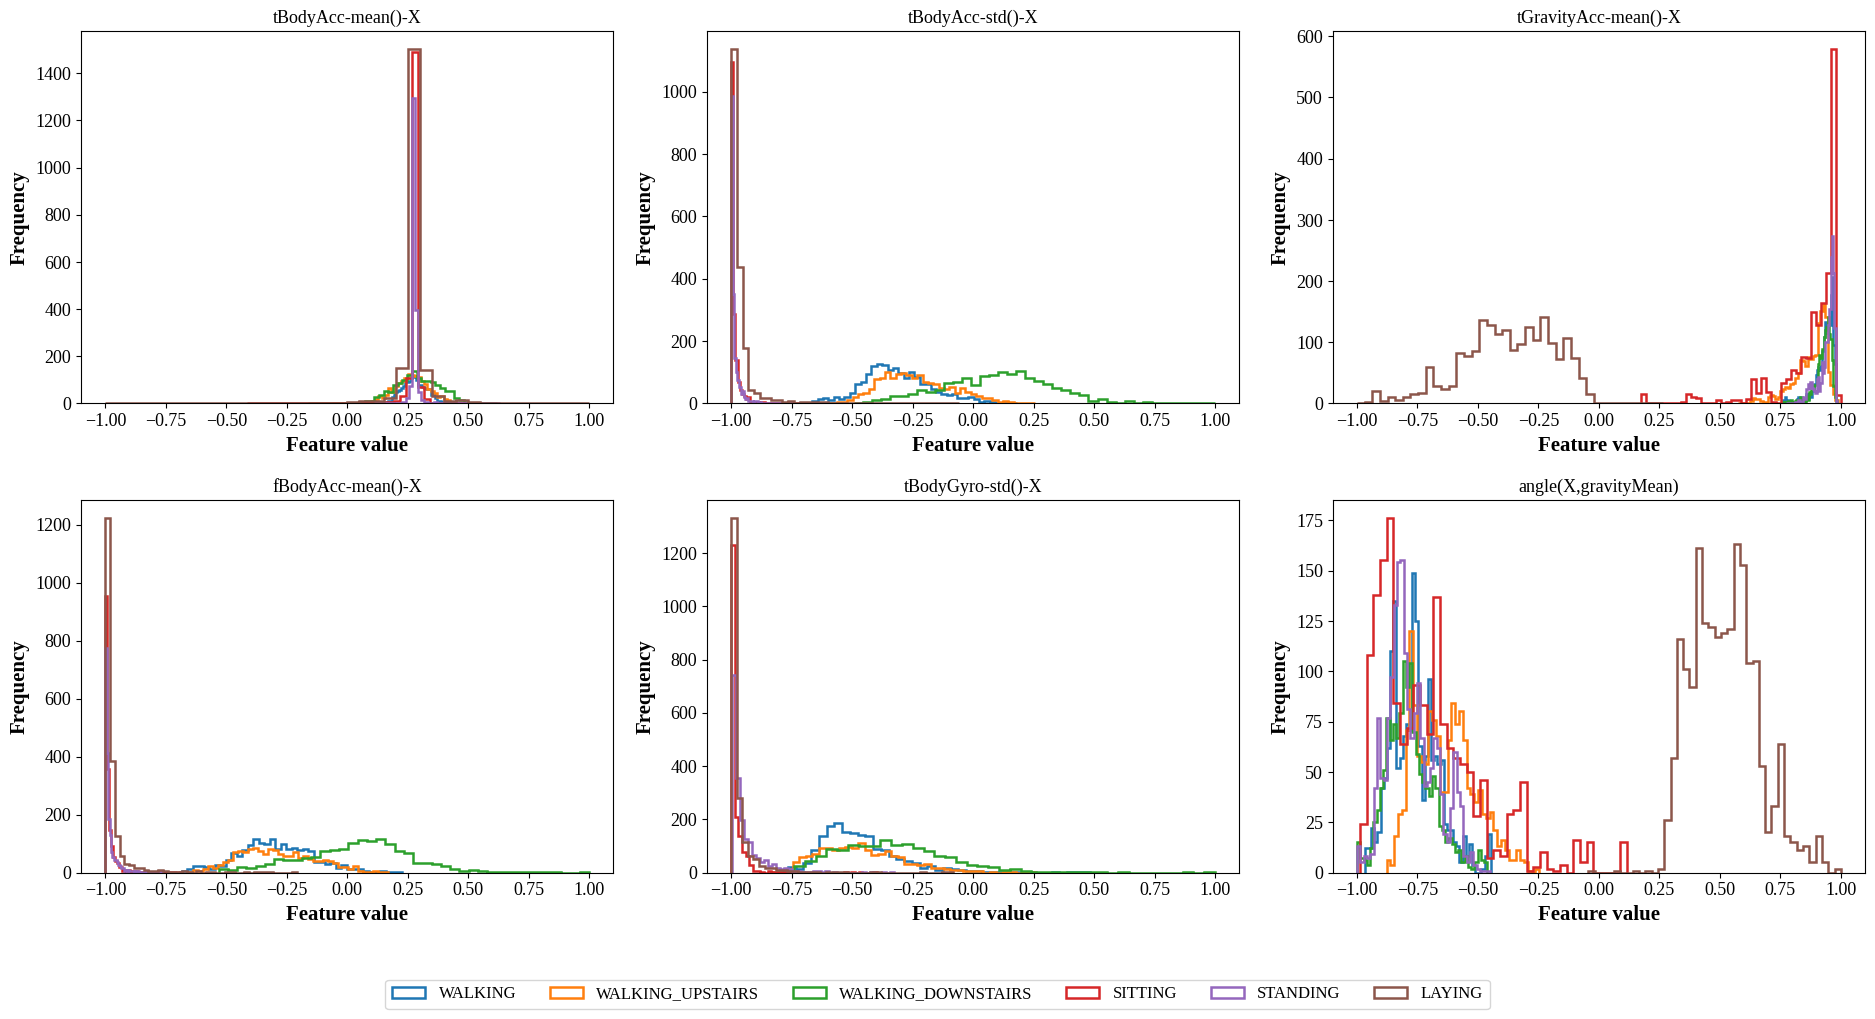

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig03_feature_std_before_scaling.eps and .png


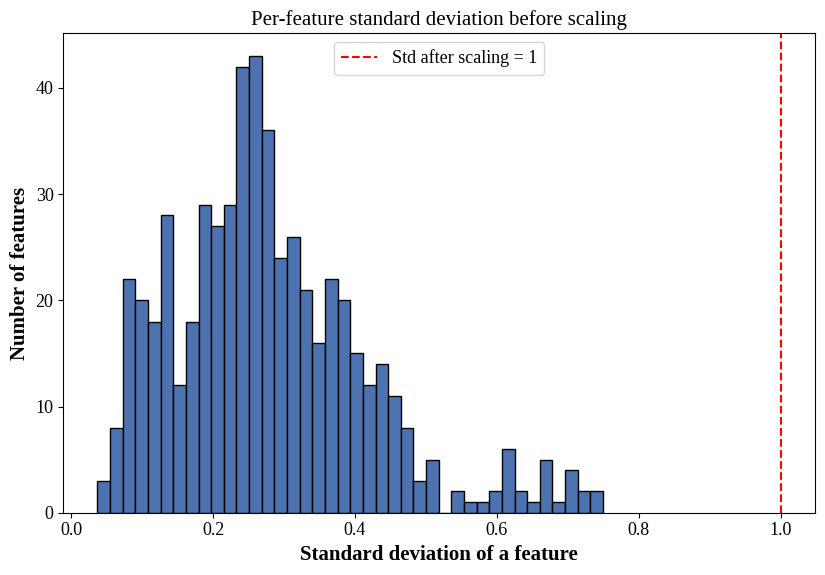

In [10]:
wanted = ["tBodyAcc-mean()-X", "tBodyAcc-std()-X", "tGravityAcc-mean()-X",
          "fBodyAcc-mean()-X", "tBodyGyro-std()-X", "angle(X,gravityMean)"]
sel = [w for w in wanted if w in X_df.columns]
print("Features plotted:", sel)

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
for ax, f in zip(axes.ravel(), sel):
    for a in ACT_NAMES:
        ax.hist(X_df.loc[meta.activity == a, f], bins=40, histtype="step", linewidth=1.8, color=ACT_COLORS[a], label=a)
    ax.set_title(f, fontsize=13); ax.set_xlabel("Feature value"); ax.set_ylabel("Frequency")
h, l = axes[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=6, fontsize=12, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(rect=(0, 0.04, 1, 1))
save_fig(fig, "fig02_feature_distributions")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.hist(raw_std, bins=40, color="#4C72B0", edgecolor="black")
ax.axvline(1.0, color="red", linestyle="--", label="Std after scaling = 1")
ax.set_title("Per-feature standard deviation before scaling")
ax.set_xlabel("Standard deviation of a feature"); ax.set_ylabel("Number of features")
ax.legend(fontsize=13)
plt.tight_layout()
save_fig(fig, "fig03_feature_std_before_scaling")
plt.show()

### 5.4 Correlation structure

Many HAR features are derived from the same signals (mean, std, energy, ...), so strong correlation is expected. A heat-map of ten representative features is shown, and the number of highly correlated feature pairs is computed over all 561 features.

Saved figures/fig04_correlation_heatmap.eps and .png


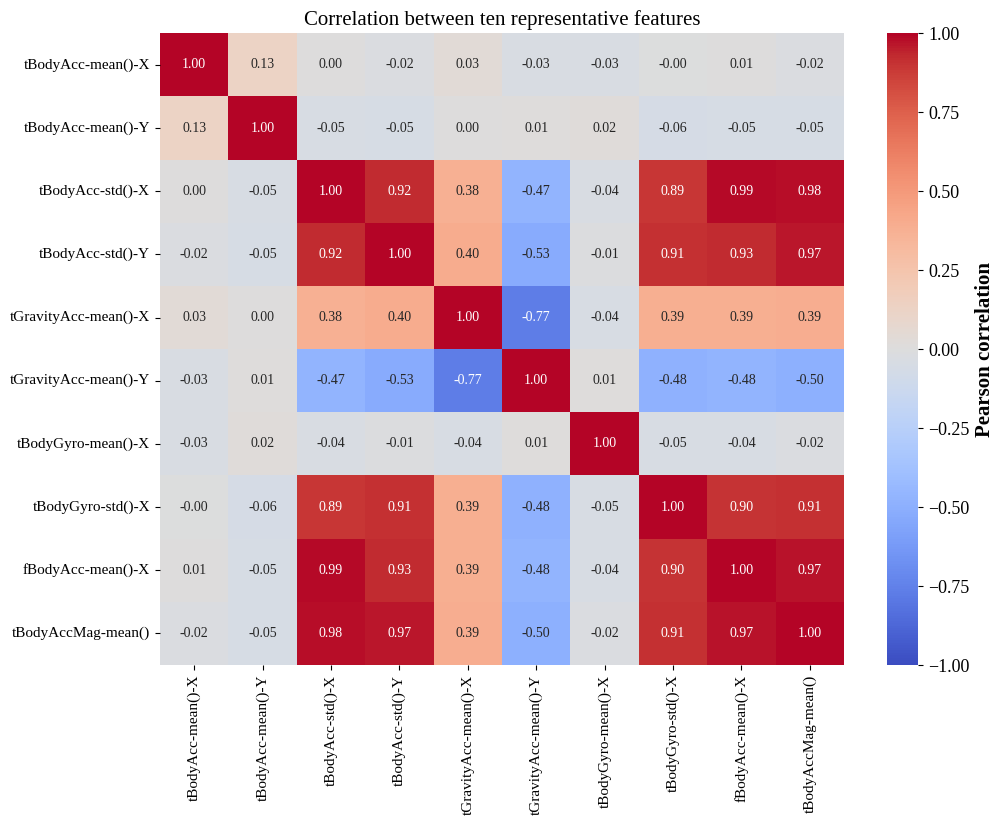

Feature pairs: 157080
Pairs with |r| > 0.9: 8093 (5.15%)
Pairs with |r| > 0.7: 36249 (23.08%)


5149

In [11]:
corr_feats = ["tBodyAcc-mean()-X", "tBodyAcc-mean()-Y", "tBodyAcc-std()-X", "tBodyAcc-std()-Y",
              "tGravityAcc-mean()-X", "tGravityAcc-mean()-Y", "tBodyGyro-mean()-X", "tBodyGyro-std()-X",
              "fBodyAcc-mean()-X", "tBodyAccMag-mean()"]
corr_feats = [c for c in corr_feats if c in X_df.columns]
fig, ax = plt.subplots(figsize=(10.5, 8.5))
sns.heatmap(X_df[corr_feats].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 10}, cbar_kws={"label": "Pearson correlation"})
ax.set_title("Correlation between ten representative features")
ax.tick_params(axis="both", labelsize=11)
plt.tight_layout()
save_fig(fig, "fig04_correlation_heatmap")
plt.show()

C = np.corrcoef(X_scaled, rowvar=False)
iu = np.triu_indices(P, k=1)
abs_c = np.abs(C[iu])
n_pairs = int(abs_c.size)
corr_stats = {"n_pairs": n_pairs, "n_abs_gt_0.9": int((abs_c > 0.9).sum()), "pct_abs_gt_0.9": float(100 * (abs_c > 0.9).mean()),
              "n_abs_gt_0.7": int((abs_c > 0.7).sum()), "pct_abs_gt_0.7": float(100 * (abs_c > 0.7).mean())}
print("Feature pairs:", n_pairs)
print("Pairs with |r| > 0.9: %d (%.2f%%)" % (corr_stats["n_abs_gt_0.9"], corr_stats["pct_abs_gt_0.9"]))
print("Pairs with |r| > 0.7: %d (%.2f%%)" % (corr_stats["n_abs_gt_0.7"], corr_stats["pct_abs_gt_0.7"]))
RESULTS["correlation"] = corr_stats
del C, iu, abs_c; gc.collect()

### 5.5 PCA: variance structure and 2-D representation

PCA is fitted on the standardised data. The first two principal components form the **2-D representation used for every cluster plot** in this notebook (the clustering algorithms themselves are run in the full 561-dimensional standardised space, not on the 2-D projection). The ground-truth activities are drawn here to show what the 2-D view looks like.

Explained variance: PC1 = 50.74%, PC2 = 6.24%, PC1+PC2 = 56.98%
Components for 90% / 95% / 99% variance: 65 / 104 / 182 (of 561)


Saved figures/fig05_pca_scree.eps and .png


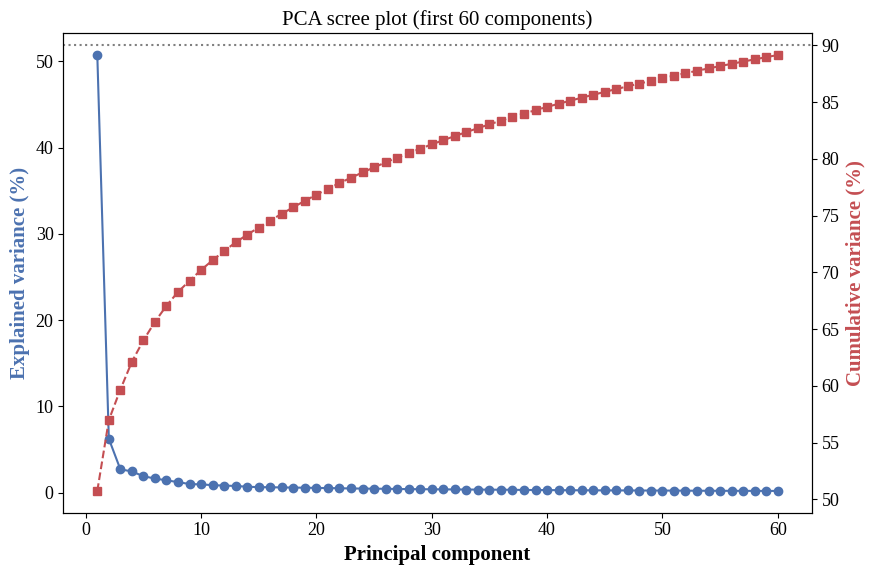

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig06_pca_ground_truth.eps and .png


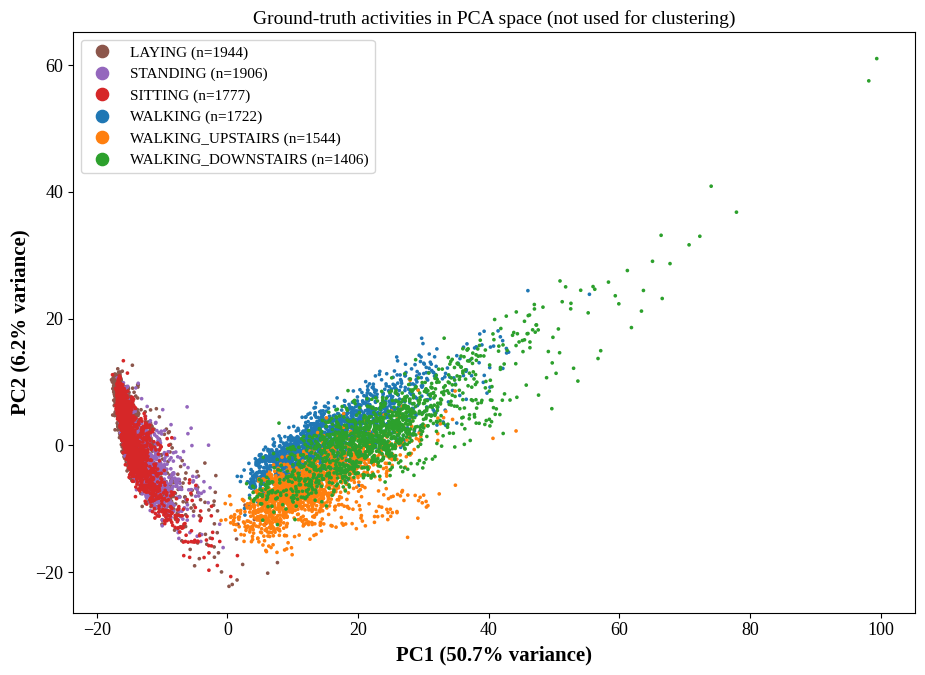

In [12]:
pca = PCA(n_components=None, svd_solver="full", random_state=RANDOM_STATE).fit(X_scaled)
Z_all = pca.transform(X_scaled)
Z2 = Z_all[:, :2]
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
n90, n95, n99 = [int(np.searchsorted(cum, t) + 1) for t in (0.90, 0.95, 0.99)]
print("Explained variance: PC1 = %.2f%%, PC2 = %.2f%%, PC1+PC2 = %.2f%%" % (100*evr[0], 100*evr[1], 100*cum[1]))
print("Components for 90%% / 95%% / 99%% variance: %d / %d / %d (of %d)" % (n90, n95, n99, P))
RESULTS["pca"] = {"pc1": float(evr[0]), "pc2": float(evr[1]), "pc12": float(cum[1]), "n90": n90, "n95": n95, "n99": n99}
XL = f"PC1 ({100*evr[0]:.1f}% variance)"; YL = f"PC2 ({100*evr[1]:.1f}% variance)"

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(np.arange(1, 61), 100 * evr[:60], "o-", color="#4C72B0", label="Individual")
ax.set_xlabel("Principal component"); ax.set_ylabel("Explained variance (%)", color="#4C72B0")
ax2 = ax.twinx(); ax2.plot(np.arange(1, 61), 100 * cum[:60], "s--", color="#C44E52", label="Cumulative")
ax2.set_ylabel("Cumulative variance (%)", color="#C44E52")
ax2.axhline(90, color="gray", linestyle=":"); ax.set_title("PCA scree plot (first 60 components)")
plt.tight_layout()
save_fig(fig, "fig05_pca_scree")
plt.show()

def plot_clusters(ax, Z, labels, title, noise_label=-1, max_legend=8, legend_fs=12, xl=None, yl=None, names=None, colors=None):
    """2-D scatter coloured by cluster. Noise (label -1) is drawn as light-grey crosses. Larger clusters are drawn first so
    that small clusters stay visible. Only the `max_legend` largest clusters get a legend entry."""
    labels = np.asarray(labels)
    uniq = [u for u in np.unique(labels) if u != noise_label]
    sizes = {u: int((labels == u).sum()) for u in uniq}
    order = sorted(uniq, key=lambda u: -sizes[u])
    cmap = plt.get_cmap("tab10") if len(order) <= 10 else plt.get_cmap("tab20")
    handles = []
    if (labels == noise_label).any():
        m = labels == noise_label
        ax.scatter(Z[m, 0], Z[m, 1], s=8, c="lightgray", marker="x", linewidths=0.7)
        handles.append(Line2D([0], [0], marker="x", color="lightgray", linestyle="", markersize=8, label=f"Noise (n={int(m.sum())})"))
    for rank, u in enumerate(order):
        m = labels == u
        col = colors[u] if colors is not None else cmap(rank % cmap.N)
        ax.scatter(Z[m, 0], Z[m, 1], s=7, color=col, edgecolors="none")
        if rank < max_legend:
            nm = names[u] if names is not None else f"Cluster {u}"
            handles.append(Line2D([0], [0], marker="o", color=col, linestyle="", markersize=8, label=f"{nm} (n={sizes[u]})"))
    if len(order) > max_legend:
        handles.append(Line2D([0], [0], linestyle="", label=f"+ {len(order) - max_legend} smaller clusters"))
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xl or XL); ax.set_ylabel(yl or YL)
    ax.legend(handles=handles, fontsize=legend_fs, loc="best", markerscale=1.1)

fig, ax = plt.subplots(figsize=(9.5, 7))
plot_clusters(ax, Z2, y_true, "Ground-truth activities in PCA space (not used for clustering)",
              names={i: n for i, n in enumerate(ACT_NAMES)}, colors={i: ACT_COLORS[n] for i, n in enumerate(ACT_NAMES)}, legend_fs=11)
plt.tight_layout()
save_fig(fig, "fig06_pca_ground_truth")
plt.show()

## 6. Evaluation Helper

One function computes every metric so that all algorithms are scored identically.

* **Internal metrics** (Silhouette, Davies–Bouldin, Calinski–Harabasz) are computed in the **standardised 561-D space**, on the non-noise points only (DBSCAN noise has no cluster, so it cannot be scored), and only when at least 2 clusters exist. For K-Means and hierarchical clustering there is no noise, so all 10,299 points are used.
* **External metrics** (ARI, NMI) compare cluster labels with the true activities. Primary values (`ARI`, `NMI`) use **all points, with DBSCAN noise treated as one extra group** (so noise is penalised, not hidden). Values restricted to non-noise points (`ARI_core`, `NMI_core`) are also recorded for DBSCAN. For methods without noise both versions are identical.

In [13]:
def evaluate_clustering(X, labels, y, noise_label=-1):
    labels = np.asarray(labels)
    noise = labels == noise_label
    core = ~noise
    n_clusters = int(len(np.unique(labels[core])))
    out = {"clusters": n_clusters, "noise": int(noise.sum())}
    if n_clusters >= 2 and int(core.sum()) > n_clusters:
        Xc, lc = (X, labels) if not noise.any() else (X[core], labels[core])
        out["Silhouette"] = float(silhouette_score(Xc, lc))
        out["Davies-Bouldin"] = float(davies_bouldin_score(Xc, lc))
        out["Calinski-Harabasz"] = float(calinski_harabasz_score(Xc, lc))
    else:
        out["Silhouette"] = out["Davies-Bouldin"] = out["Calinski-Harabasz"] = np.nan
    out["ARI"] = float(adjusted_rand_score(y, labels))
    out["NMI"] = float(normalized_mutual_info_score(y, labels))
    if noise.any() and core.sum() > 1:
        out["ARI_core"] = float(adjusted_rand_score(y[core], labels[core]))
        out["NMI_core"] = float(normalized_mutual_info_score(y[core], labels[core]))
    else:
        out["ARI_core"], out["NMI_core"] = out["ARI"], out["NMI"]
    return out

# Sanity check of the helper on a trivial input (must equal direct sklearn calls)
_t = KMeans(3, n_init=3, random_state=RANDOM_STATE).fit(X_scaled).labels_
_e = evaluate_clustering(X_scaled, _t, y_true)
assert np.isclose(_e["Silhouette"], silhouette_score(X_scaled, _t)) and np.isclose(_e["ARI"], adjusted_rand_score(y_true, _t))
print("evaluate_clustering() sanity check passed.")

evaluate_clustering() sanity check passed.


## 7. Model A – K-Means

K-Means partitions the data into *k* clusters by minimising the within-cluster sum of squares (WCSS, `inertia_`):
$$\mathrm{WCSS}=\sum_{j=1}^{k}\sum_{x_i\in C_j}\lVert x_i-\mu_j\rVert^2 .$$
It is run for $k=2,\dots,8$ with `n_init=10` (best of 10 k-means++ initialisations) and `random_state=42`. For each *k* the WCSS and the Silhouette Score are recorded (Table 1); the other metrics are also stored to study the sensitivity of K-Means to *k*.

**How the final *k* is chosen:** the number of true activities (6) is deliberately *not* assumed. The final *k* is the value with the highest Silhouette Score (an internal criterion), cross-checked against the elbow of the WCSS curve located objectively with the maximum-distance-to-chord rule. External metrics (ARI/NMI) are reported afterwards but are not used to select *k*.

In [14]:
K_RANGE = list(range(2, 9))
km_rows, KM_MODELS, KM_LABELS = [], {}, {}
for k in K_RANGE:
    t0 = time.time()
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    KM_MODELS[k], KM_LABELS[k] = km, km.labels_
    m = evaluate_clustering(X_scaled, km.labels_, y_true)
    km_rows.append({"k": k, "WCSS": float(km.inertia_), "Silhouette": m["Silhouette"],
                    "Davies-Bouldin": m["Davies-Bouldin"], "Calinski-Harabasz": m["Calinski-Harabasz"],
                    "ARI": m["ARI"], "NMI": m["NMI"], "n_iter": int(km.n_iter_)})
    print(f"k={k}: WCSS={km.inertia_:,.1f}  Silhouette={m['Silhouette']:.4f}  ({time.time()-t0:.1f}s)")

km_tbl = pd.DataFrame(km_rows)
km_tbl["WCSS_reduction_pct"] = 100 * (-km_tbl["WCSS"].diff() / km_tbl["WCSS"].shift(1))

k=2: WCSS=3,272,856.6  Silhouette=0.3937  (2.4s)


k=3: WCSS=2,921,077.6  Silhouette=0.3155  (3.1s)


k=4: WCSS=2,781,602.1  Silhouette=0.1500  (3.2s)


k=5: WCSS=2,654,789.8  Silhouette=0.1286  (4.4s)


k=6: WCSS=2,577,180.4  Silhouette=0.1099  (4.7s)


k=7: WCSS=2,519,774.2  Silhouette=0.0816  (5.9s)


k=8: WCSS=2,465,379.0  Silhouette=0.0749  (5.1s)


### 7.1 Table 1 – K-Means elbow / silhouette results

In [15]:
table1 = km_tbl[["k", "WCSS", "Silhouette"]].copy()
save_table(table1, "table1_kmeans_elbow_silhouette")
save_table(km_tbl, "table1b_kmeans_all_metrics_vs_k")
print("Table 1 - K-Means Elbow Method Results")
display(table1.style.format({"WCSS": "{:,.1f}", "Silhouette": "{:.4f}"}).hide(axis="index"))
print("Extended metrics for each k (used for the sensitivity analysis):")
display(km_tbl.round(4))

Saved tables/table1_kmeans_elbow_silhouette.csv  (7 rows)
Saved tables/table1b_kmeans_all_metrics_vs_k.csv  (7 rows)
Table 1 - K-Means Elbow Method Results


k,WCSS,Silhouette
2,"3,272,856.6",0.3937
3,"2,921,077.6",0.3155
4,"2,781,602.1",0.1500
5,"2,654,789.8",0.1286
6,"2,577,180.4",0.1099
7,"2,519,774.2",0.0816
8,"2,465,379.0",0.0749


Extended metrics for each k (used for the sensitivity analysis):


,k,WCSS,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,n_iter,WCSS_reduction_pct
0,2,3.272857e+06,0.3937,1.0707,7880.8139,0.3296,0.5455,5,NaN
1,3,2.921078e+06,0.3155,1.7865,5034.4753,0.3317,0.5183,12,10.7484
2,4,2.781602e+06,0.1500,2.3422,3696.3387,0.2990,0.4694,17,4.7748
3,5,2.654790e+06,0.1286,2.4108,3027.3244,0.2912,0.4607,20,4.5590
4,6,2.577180e+06,0.1099,2.3836,2556.5419,0.4196,0.5593,36,2.9234
5,7,2.519774e+06,0.0816,2.6752,2217.8557,0.4332,0.5546,19,2.2275
6,8,2.465379e+06,0.0749,2.6106,1975.2107,0.4266,0.5516,33,2.1587


### 7.2 Elbow curve and silhouette curve

Elbow (max distance-to-chord) suggests k = 4 | chord distances: [0.     0.1902 0.1945 0.1877 0.1378 0.0702 0.    ]
Highest Silhouette at k = 2 (0.3937)
Second-highest Silhouette at k = 3 (0.3155)

Relative WCSS reduction when moving from k-1 to k (%):


,k,WCSS,WCSS_reduction_pct
0,2,3272856.615,NaN
1,3,2921077.599,10.748
2,4,2781602.140,4.775
3,5,2654789.787,4.559
4,6,2577180.429,2.923
5,7,2519774.217,2.227
6,8,2465378.960,2.159


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig07_kmeans_elbow.eps and .png


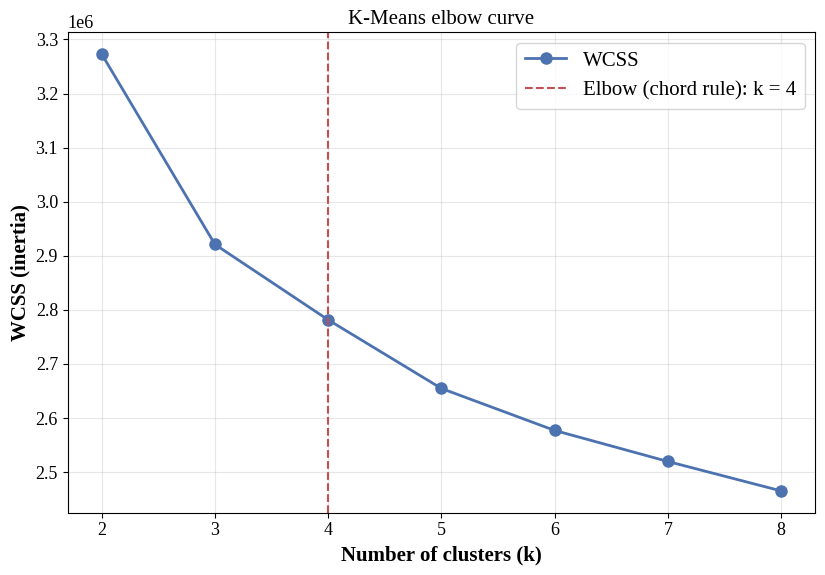

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig08_kmeans_silhouette.eps and .png


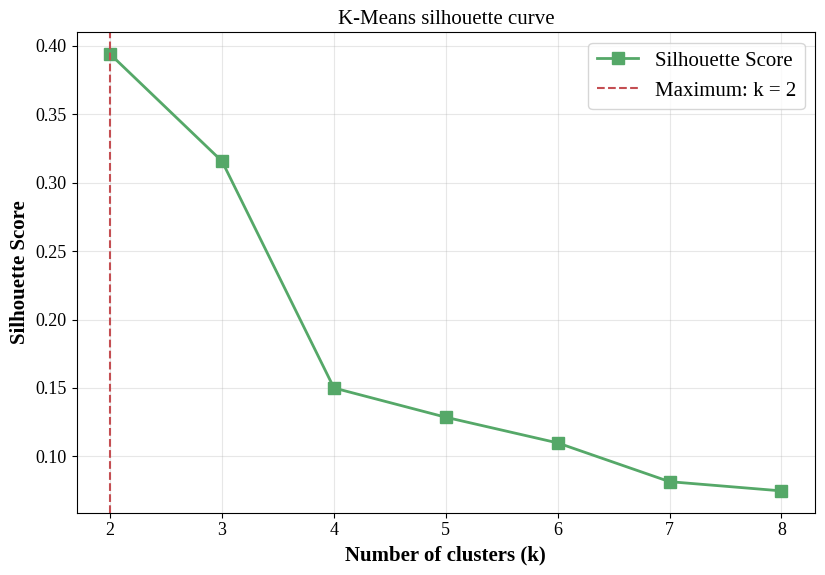

In [16]:
ks = km_tbl["k"].to_numpy(dtype=float); wcss = km_tbl["WCSS"].to_numpy(); sil = km_tbl["Silhouette"].to_numpy()

def elbow_by_chord(ks, wcss):
    """Elbow = point with the largest perpendicular distance from the chord joining the first and last points
    of the (min-max normalised) k-vs-WCSS curve."""
    x = (ks - ks.min()) / (ks.max() - ks.min()); y = (wcss - wcss.min()) / (wcss.max() - wcss.min())
    dx, dy = x[-1] - x[0], y[-1] - y[0]
    d = np.abs(dx * (y - y[0]) - dy * (x - x[0])) / np.hypot(dx, dy)
    return int(ks[np.argmax(d)]), d

k_elbow, chord_d = elbow_by_chord(ks, wcss)
k_final = int(ks[np.argmax(sil)])
print("Elbow (max distance-to-chord) suggests k =", k_elbow, "| chord distances:", np.round(chord_d, 4))
print("Highest Silhouette at k =", k_final, "(%.4f)" % sil.max())
print("Second-highest Silhouette at k =", int(ks[np.argsort(sil)[-2]]), "(%.4f)" % np.sort(sil)[-2])
print("\nRelative WCSS reduction when moving from k-1 to k (%):")
display(km_tbl[["k", "WCSS", "WCSS_reduction_pct"]].round(3))
RESULTS["kmeans"] = {"k_final": k_final, "k_elbow": k_elbow, "chord_distance": chord_d.tolist(),
                     "criterion": "highest Silhouette Score (internal); elbow via max distance-to-chord as cross-check"}

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.plot(ks, wcss, "o-", color="#4C72B0", linewidth=2, markersize=8, label="WCSS")
ax.axvline(k_elbow, color="#C44E52", linestyle="--", label=f"Elbow (chord rule): k = {k_elbow}")
ax.set_title("K-Means elbow curve"); ax.set_xlabel("Number of clusters (k)"); ax.set_ylabel("WCSS (inertia)")
ax.set_xticks(K_RANGE); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); save_fig(fig, "fig07_kmeans_elbow"); plt.show()

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.plot(ks, sil, "s-", color="#55A868", linewidth=2, markersize=8, label="Silhouette Score")
ax.axvline(k_final, color="#C44E52", linestyle="--", label=f"Maximum: k = {k_final}")
ax.set_title("K-Means silhouette curve"); ax.set_xlabel("Number of clusters (k)"); ax.set_ylabel("Silhouette Score")
ax.set_xticks(K_RANGE); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); save_fig(fig, "fig08_kmeans_silhouette"); plt.show()

### 7.3 K-Means cluster visualisation (PCA)

The selected *k* is shown next to *k* = 6 (the number of true activities) as a **reference only**, so that the effect of the *k* choice can be seen. Clusters are found in the 561-D space and merely *displayed* on the first two principal components.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig09_kmeans_pca_clusters.eps and .png


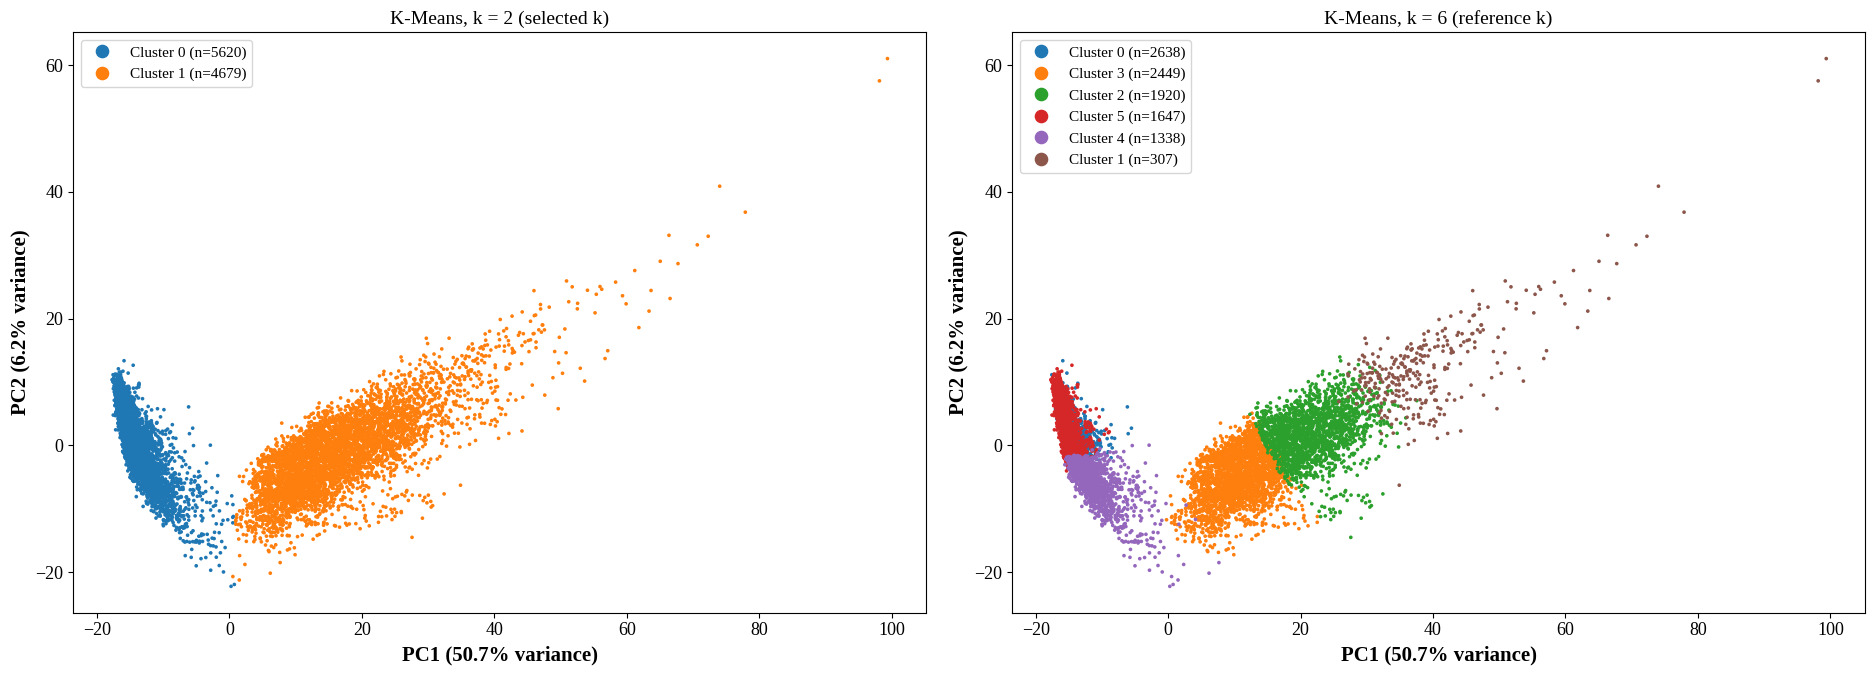

In [17]:
REF_K = 6
km_view_ks = sorted({k_final, REF_K})
fig, axes = plt.subplots(1, len(km_view_ks), figsize=(9.5 * len(km_view_ks), 7))
axes = np.atleast_1d(axes)
for ax, k in zip(axes, km_view_ks):
    tag = "selected k" if k == k_final else "reference k"
    plot_clusters(ax, Z2, KM_LABELS[k], f"K-Means, k = {k} ({tag})", legend_fs=11)
plt.tight_layout(); save_fig(fig, "fig09_kmeans_pca_clusters"); plt.show()

## 8. Model B – DBSCAN

DBSCAN labels a point as a **core point** if at least `min_samples` points (itself included) lie within radius `eps`; clusters are the density-connected sets of core points plus their **border points**, and everything else is **noise** (label −1). Unlike K-Means, the number of clusters is not specified.

Both parameters are tuned on the **standardised 561-D data** (Euclidean distance), so `eps` is measured in standardised units.

### 8.1 Choosing a sensible `eps` range – k-distance plot

For each `min_samples` value, the sorted distance of every point to its `min_samples`-th nearest neighbour (the point itself counts as the first) is plotted. The values of `eps` where this curve bends upward mark the transition from dense regions to sparse points/noise. The percentiles are printed so that the tested grid can be justified from the data itself.

Percentiles of the distance to the min_samples-th nearest neighbour (standardised units):


,min_samples,p5,p25,p50,p75,p90,p95,p99
0,5,9.18,10.51,12.32,15.13,18.25,20.98,28.75
1,10,9.66,11.05,13.07,16.03,19.29,22.13,30.80
2,20,10.05,11.54,13.78,16.94,20.37,23.32,33.17
3,50,10.53,12.19,14.79,18.06,21.88,25.11,35.93


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved tables/table_dbscan_kdistance_percentiles.csv  (4 rows)


Saved figures/fig10_dbscan_kdistance.eps and .png


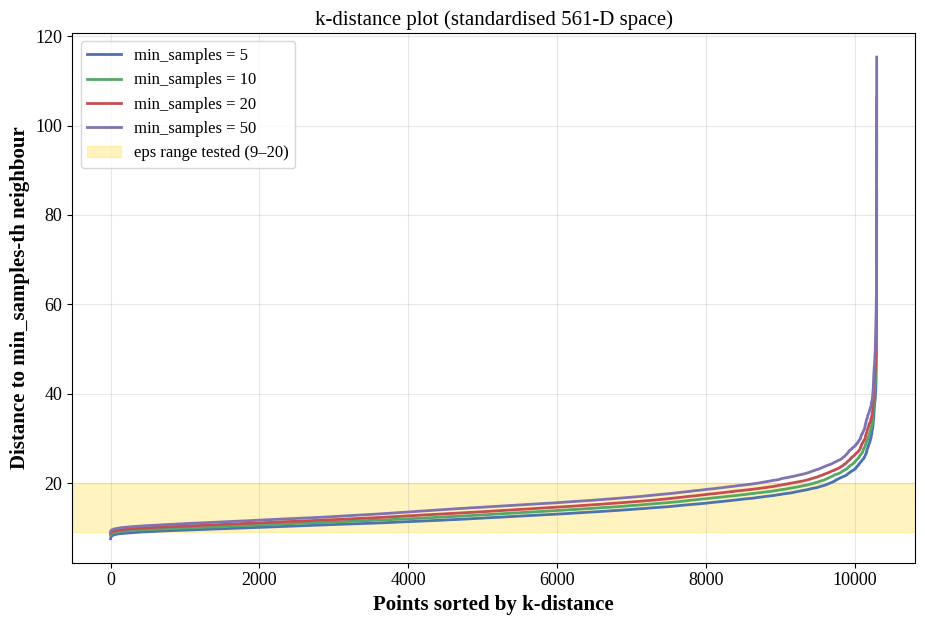

In [18]:
MS_LIST = [5, 10, 20, 50]
nn_k = NearestNeighbors(n_neighbors=max(MS_LIST), algorithm="brute").fit(X_scaled)
kd_dist, _ = nn_k.kneighbors(X_scaled)
kd_rows = []
for ms in MS_LIST:
    d = kd_dist[:, ms - 1]
    pct = np.percentile(d, [5, 25, 50, 75, 90, 95, 99])
    kd_rows.append({"min_samples": ms, **{f"p{p}": v for p, v in zip([5, 25, 50, 75, 90, 95, 99], pct)}})
kd_tbl = pd.DataFrame(kd_rows)
print("Percentiles of the distance to the min_samples-th nearest neighbour (standardised units):")
display(kd_tbl.round(2))
save_table(kd_tbl, "table_dbscan_kdistance_percentiles")

EPS_GRID = [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20]
fig, ax = plt.subplots(figsize=(9.5, 6.5))
for ms, c in zip(MS_LIST, ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]):
    ax.plot(np.sort(kd_dist[:, ms - 1]), color=c, linewidth=2, label=f"min_samples = {ms}")
ax.axhspan(min(EPS_GRID), max(EPS_GRID), color="gold", alpha=0.25, label=f"eps range tested ({min(EPS_GRID)}–{max(EPS_GRID)})")
ax.set_title("k-distance plot (standardised 561-D space)")
ax.set_xlabel("Points sorted by k-distance"); ax.set_ylabel("Distance to min_samples-th neighbour")
ax.legend(fontsize=12); ax.grid(alpha=0.3)
plt.tight_layout(); save_fig(fig, "fig10_dbscan_kdistance"); plt.show()

### 8.2 Parameter grid search

The grid is `eps` ∈ {9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20} × `min_samples` ∈ {5, 10, 20, 50}. The upper end of `eps` is capped at 20 because (a) the k-distance percentiles above show that beyond about this radius almost every point is a core point, and (b) a neighbour graph for much larger radii becomes almost fully dense (10,299² entries), which does not fit in memory.

To avoid recomputing 10,299² distances 44 times, one sparse radius-neighbour graph (radius = max `eps`) is built once and passed to `sklearn.cluster.DBSCAN(metric="precomputed")`, which only keeps the entries within each configuration's `eps`. This gives the same neighbourhoods as running DBSCAN directly; the cell after the grid verifies this on the selected configuration.

In [19]:
EPS_MAX = max(EPS_GRID)
t0 = time.time()
G = NearestNeighbors(radius=EPS_MAX, algorithm="brute").fit(X_scaled).radius_neighbors_graph(X_scaled, mode="distance")
G = sort_graph_by_row_values(G, warn_when_not_sorted=False)
print(f"Neighbour graph built in {time.time()-t0:.1f}s: {G.nnz:,} stored entries "
      f"({100*G.nnz/(N*N):.1f}% of a dense {N}x{N} matrix), approx. {G.data.nbytes/1e6 + G.indices.nbytes/1e6:.0f} MB")

db_rows, DB_LABELS = [], {}
t_grid = time.time()
for ms in MS_LIST:
    for eps in EPS_GRID:
        lab = DBSCAN(eps=eps, min_samples=ms, metric="precomputed").fit(G).labels_
        DB_LABELS[(eps, ms)] = lab
        m = evaluate_clustering(X_scaled, lab, y_true)
        clustered = N - m["noise"]
        sizes = np.bincount(lab[lab >= 0]) if m["clusters"] > 0 else np.array([0])
        db_rows.append({"eps": eps, "min_samples": ms, "clusters": m["clusters"], "noise": m["noise"],
                        "noise_pct": 100 * m["noise"] / N,
                        "largest_cluster_pct": (100 * sizes.max() / clustered) if clustered > 0 else np.nan,
                        "smallest_cluster": int(sizes.min()) if m["clusters"] > 0 else 0,
                        "Silhouette": m["Silhouette"], "Davies-Bouldin": m["Davies-Bouldin"],
                        "Calinski-Harabasz": m["Calinski-Harabasz"], "ARI": m["ARI"], "NMI": m["NMI"],
                        "ARI_core": m["ARI_core"], "NMI_core": m["NMI_core"]})
        print(f"eps={eps:>2}, min_samples={ms:>2}: clusters={m['clusters']:>3}, noise={m['noise']:>5} ({100*m['noise']/N:5.1f}%), "
              f"Sil={m['Silhouette']:.3f}, ARI={m['ARI']:.3f}   [{time.time()-t_grid:.0f}s]")
del G; free_memory()
grid_df = pd.DataFrame(db_rows)
print(f"\nGrid search finished: {len(grid_df)} configurations in {time.time()-t_grid:.0f}s")

Neighbour graph built in 4.6s: 22,265,699 stored entries (21.0% of a dense 10299x10299 matrix), approx. 267 MB


eps= 9, min_samples= 5: clusters= 35, noise= 9422 ( 91.5%), Sil=-0.001, ARI=0.000   [1s]


eps=10, min_samples= 5: clusters= 25, noise= 7545 ( 73.3%), Sil=-0.035, ARI=0.047   [1s]


eps=11, min_samples= 5: clusters= 43, noise= 5893 ( 57.2%), Sil=0.019, ARI=0.134   [2s]


eps=12, min_samples= 5: clusters= 34, noise= 4623 ( 44.9%), Sil=0.089, ARI=0.205   [4s]


...

eps=15, min_samples=50: clusters=  1, noise= 3164 ( 30.7%), Sil=nan, ARI=0.112   [53s]


eps=16, min_samples=50: clusters=  1, noise= 2468 ( 24.0%), Sil=nan, ARI=0.083   [54s]


eps=17, min_samples=50: clusters=  1, noise= 1881 ( 18.3%), Sil=nan, ARI=0.057   [55s]


eps=18, min_samples=50: clusters=  1, noise= 1363 ( 13.2%), Sil=nan, ARI=0.033   [56s]


eps=20, min_samples=50: clusters=  1, noise=  700 (  6.8%), Sil=nan, ARI=0.012   [56s]

Grid search finished: 44 configurations in 57s


### 8.3 Table 3 – DBSCAN parameter tuning (all tested configurations)

`Silhouette`, `Davies-Bouldin` and `Calinski-Harabasz` are computed on the non-noise points only and are `NaN` when fewer than 2 clusters exist (metric undefined). `ARI` / `NMI` use all points with noise as one extra group; `ARI_core` / `NMI_core` exclude noise points.

In [20]:
save_table(grid_df, "table3_dbscan_parameter_tuning")
show_cols = ["eps", "min_samples", "clusters", "noise", "noise_pct", "largest_cluster_pct", "Silhouette", "Davies-Bouldin",
             "Calinski-Harabasz", "ARI", "NMI", "ARI_core", "NMI_core"]
with pd.option_context("display.max_rows", 100, "display.width", 250):
    display(grid_df[show_cols].round(3))

Saved tables/table3_dbscan_parameter_tuning.csv  (44 rows)


,eps,min_samples,clusters,noise,noise_pct,largest_cluster_pct,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,ARI_core,NMI_core
0,9,5,35,9422,91.485,66.819,-0.001,1.746,23.815,0.000,0.098,0.347,0.502
1,10,5,25,7545,73.260,89.833,-0.035,1.608,38.661,0.047,0.182,0.088,0.271
2,11,5,43,5893,57.219,86.882,0.019,1.773,59.759,0.134,0.287,0.161,0.405
3,12,5,34,4623,44.888,80.620,0.089,2.029,128.245,0.205,0.374,0.232,0.500
4,13,5,25,3591,34.867,73.539,0.306,1.766,236.239,0.254,0.401,0.277,0.502
5,14,5,22,2687,26.090,68.142,0.160,1.555,320.953,0.299,0.443,0.309,0.527
6,15,5,19,2029,19.701,97.654,0.143,1.341,30.644,0.066,0.148,0.006,0.050
7,16,5,13,1461,14.186,98.235,0.183,1.366,37.323,0.043,0.121,0.003,0.037
8,17,5,5,1034,10.040,99.428,0.101,1.088,41.246,0.025,0.083,0.000,0.012
9,18,5,3,746,7.243,99.466,0.285,0.943,78.918,0.016,0.067,0.001,0.012


### 8.4 Selecting the "best" DBSCAN configuration (internal criteria only)

A raw maximum of the Silhouette Score would reward degenerate solutions (e.g. one giant cluster plus a handful of tiny clusters, or hardly any points clustered). A configuration is therefore called **useful** only if it satisfies all of:

* at least 2 clusters (internal metrics are defined),
* noise ≤ 20 % of all points,
* the largest cluster holds ≤ 90 % of the clustered points (i.e. it is not one blob).

Among useful configurations the one with the highest Silhouette Score is selected. If no configuration is useful, the rule is relaxed step by step and this is stated explicitly. No ground-truth information is used.

In [21]:
def select_dbscan(g):
    rules = [
        ("clusters>=2, noise<=20%, largest cluster<=90% of clustered points",
         (g.clusters >= 2) & (g.noise_pct <= 20) & (g.largest_cluster_pct <= 90)),
        ("RELAXED (1): clusters>=2, noise<=50%, largest cluster<=90% of clustered points",
         (g.clusters >= 2) & (g.noise_pct <= 50) & (g.largest_cluster_pct <= 90)),
        ("RELAXED (2): clusters>=2, noise<=50%",
         (g.clusters >= 2) & (g.noise_pct <= 50)),
        ("RELAXED (3): clusters>=2",
         (g.clusters >= 2)),
    ]
    for name, mask in rules:
        elig = g[mask].dropna(subset=["Silhouette"])
        if len(elig):
            return name, elig
    return "none", g.iloc[0:0]

rule_used, elig = select_dbscan(grid_df)
print("Rule applied:", rule_used)
print("Number of configurations satisfying it:", len(elig), "of", len(grid_df))
print("Configurations with at least 2 clusters:", int((grid_df.clusters >= 2).sum()),
      "| with exactly 1 cluster:", int((grid_df.clusters == 1).sum()), "| with 0 clusters (all noise):", int((grid_df.clusters == 0).sum()))
if len(elig):
    display(elig.sort_values("Silhouette", ascending=False)[show_cols].head(10).round(3))
    best = elig.sort_values("Silhouette", ascending=False).iloc[0]
    BEST_EPS, BEST_MS = int(best["eps"]), int(best["min_samples"])
    db_best_labels = DB_LABELS[(BEST_EPS, BEST_MS)]
    print(f"\nSelected DBSCAN configuration: eps = {BEST_EPS}, min_samples = {BEST_MS}")
else:
    raise RuntimeError("No DBSCAN configuration produced >= 2 clusters; cannot select a best configuration.")
RESULTS["dbscan"] = {"rule_used": rule_used, "n_eligible": int(len(elig)), "n_configs": int(len(grid_df)),
                     "best_eps": BEST_EPS, "best_min_samples": BEST_MS,
                     "n_ge2_clusters": int((grid_df.clusters >= 2).sum()), "n_1_cluster": int((grid_df.clusters == 1).sum()),
                     "n_0_clusters": int((grid_df.clusters == 0).sum()),
                     "eps_grid": EPS_GRID, "ms_list": MS_LIST}

Rule applied: RELAXED (1): clusters>=2, noise<=50%, largest cluster<=90% of clustered points
Number of configurations satisfying it: 8 of 44
Configurations with at least 2 clusters: 30 | with exactly 1 cluster: 13 | with 0 clusters (all noise): 1


,eps,min_samples,clusters,noise,noise_pct,largest_cluster_pct,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,ARI_core,NMI_core
38,14,50,2,4126,40.062,81.451,0.408,1.057,3343.370,0.257,0.405,0.238,0.477
26,13,20,4,4546,44.140,83.609,0.352,1.779,1020.797,0.231,0.378,0.216,0.457
27,14,20,4,3504,34.023,75.114,0.348,1.458,1577.648,0.275,0.423,0.280,0.515
16,14,10,9,3119,30.284,71.616,0.321,1.668,706.781,0.288,0.434,0.296,0.522
4,13,5,25,3591,34.867,73.539,0.306,1.766,236.239,0.254,0.401,0.277,0.502
5,14,5,22,2687,26.090,68.142,0.160,1.555,320.953,0.299,0.443,0.309,0.527
3,12,5,34,4623,44.888,80.620,0.089,2.029,128.245,0.205,0.374,0.232,0.500
15,13,10,11,4039,39.217,77.796,0.069,1.873,434.036,0.243,0.393,0.256,0.495



Selected DBSCAN configuration: eps = 14, min_samples = 50


**Independent verification of the selected DBSCAN result.** Running sklearn's `DBSCAN` a second time on the raw data would materialise all neighbour lists (very large for big `eps`), so instead the DBSCAN definition is re-derived directly, in chunks, without any DBSCAN code: (1) a point is a *core point* if at least `min_samples` points (itself included) are within `eps`; (2) a point is *noise* if it is neither a core point nor within `eps` of a core point; (3) clusters of core points are the connected components of the "within `eps`" graph restricted to core points. The selected result must agree with this on the noise set and on the core-point partition (border points that touch two clusters may legitimately be assigned to either one, so they are excluded from the partition comparison).

In [22]:
from sklearn.metrics import pairwise_distances
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

def dbscan_reference(X, eps, ms, chunk=1000):
    n = len(X)
    counts = np.zeros(n, dtype=int)
    for s in range(0, n, chunk):
        counts[s:s + chunk] = (pairwise_distances(X[s:s + chunk], X) <= eps).sum(axis=1)
    core = counts >= ms
    core_idx = np.flatnonzero(core)
    pos = np.cumsum(core) - 1                      # position of a core point inside core_idx
    reach = np.zeros(n, dtype=bool)                # core, or within eps of a core point
    rows, cols = [], []
    for s in range(0, n, chunk):
        within = pairwise_distances(X[s:s + chunk], X[core_idx]) <= eps
        reach[s:s + chunk] = within.any(axis=1)
        cm = core[s:s + chunk]
        r, c = np.nonzero(within[cm])
        rows.append(pos[s:s + chunk][cm][r]); cols.append(c)
    rows, cols = np.concatenate(rows), np.concatenate(cols)
    A = coo_matrix((np.ones(len(rows), dtype=np.int8), (rows, cols)), shape=(len(core_idx),) * 2)
    _, comp = connected_components(A, directed=False)
    return core, ~reach, core_idx, comp

t0 = time.time()
core_ref, noise_ref, core_idx_ref, comp_ref = dbscan_reference(X_scaled, BEST_EPS, BEST_MS)
noise_same = bool(((db_best_labels == -1) == noise_ref).all())
core_labels_ok = bool((db_best_labels[core_idx_ref] >= 0).all())
ari_core_partition = adjusted_rand_score(comp_ref, db_best_labels[core_idx_ref])
print(f"Independent check ({time.time()-t0:.0f}s): core points = {int(core_ref.sum())}, noise (reference) = {int(noise_ref.sum())}, noise (selected result) = {int((db_best_labels == -1).sum())}")
print(f"  noise set identical        : {noise_same}")
print(f"  all core points clustered  : {core_labels_ok}")
print(f"  core-point partition ARI   : {ari_core_partition:.6f} (1.0 = identical partition)")
RESULTS["dbscan"]["independent_check"] = {"noise_identical": noise_same, "core_points_all_clustered": core_labels_ok,
                                          "core_partition_ari": float(ari_core_partition), "n_core_points": int(core_ref.sum())}
del core_ref, noise_ref, core_idx_ref, comp_ref; gc.collect()

Independent check (3s): core points = 4386, noise (reference) = 4126, noise (selected result) = 4126
  noise set identical        : True
  all core points clustered  : True
  core-point partition ARI   : 1.000000 (1.0 = identical partition)


0

### 8.5 Tuning heat-maps and DBSCAN cluster visualisation

Saved figures/fig11_dbscan_tuning_heatmaps.eps and .png


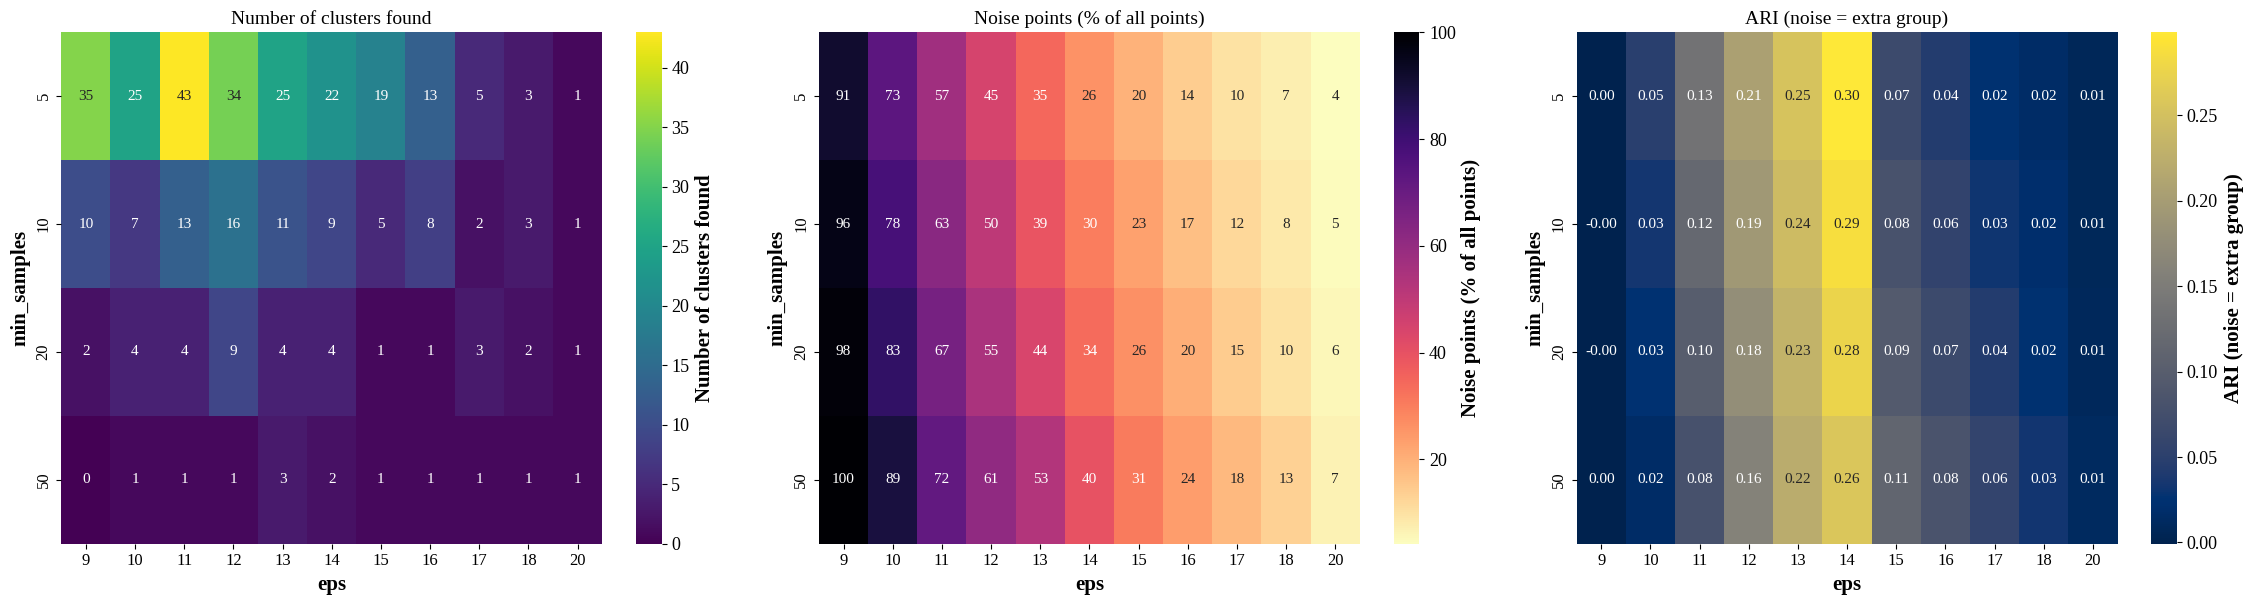

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig12_dbscan_pca_clusters.eps and .png


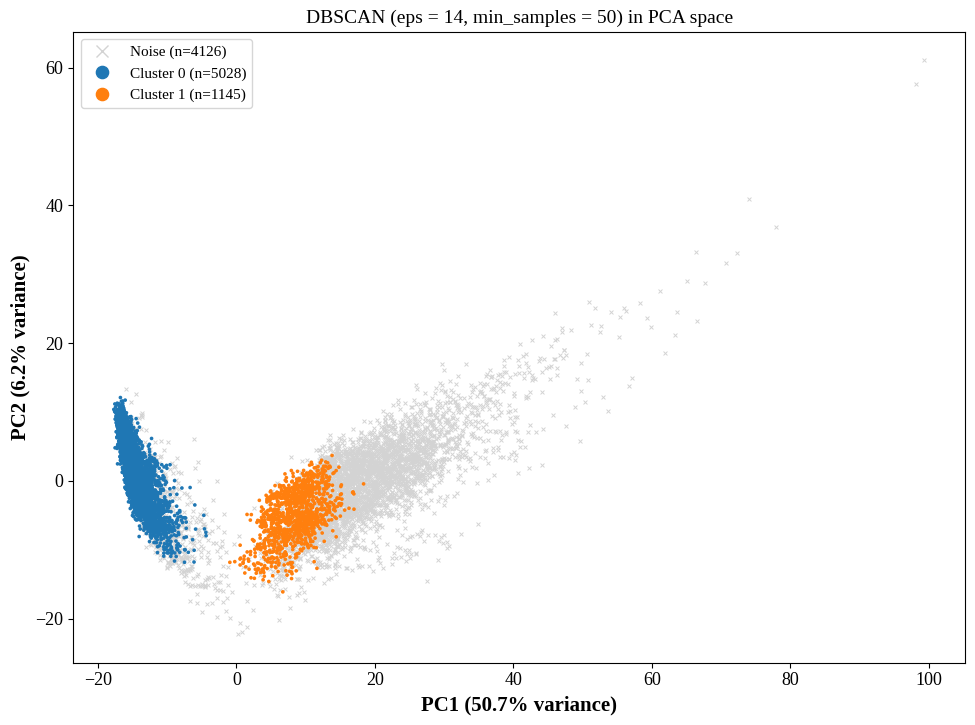

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(23, 6.3))
for ax, (col, ttl, fmt, cmap) in zip(axes, [("clusters", "Number of clusters found", "d", "viridis"),
                                            ("noise_pct", "Noise points (% of all points)", ".0f", "magma_r"),
                                            ("ARI", "ARI (noise = extra group)", ".2f", "cividis")]):
    pv = grid_df.pivot(index="min_samples", columns="eps", values=col)
    sns.heatmap(pv, annot=True, fmt=fmt, cmap=cmap, ax=ax, annot_kws={"size": 11}, cbar_kws={"label": ttl})
    ax.set_title(ttl, fontsize=14); ax.set_xlabel("eps"); ax.set_ylabel("min_samples")
    ax.tick_params(axis="both", labelsize=12)
plt.tight_layout(); save_fig(fig, "fig11_dbscan_tuning_heatmaps"); plt.show()

fig, ax = plt.subplots(figsize=(10, 7.5))
plot_clusters(ax, Z2, db_best_labels, f"DBSCAN (eps = {BEST_EPS}, min_samples = {BEST_MS}) in PCA space", legend_fs=11)
plt.tight_layout(); save_fig(fig, "fig12_dbscan_pca_clusters"); plt.show()

## 9. Model C – Hierarchical Agglomerative Clustering (HAC)

Agglomerative clustering starts with every point in its own cluster and repeatedly merges the closest pair. The definition of "closest" is the **linkage**:

| Linkage | Distance between clusters A and B |
|---|---|
| Single | minimum pairwise distance (nearest neighbours) |
| Complete | maximum pairwise distance (farthest neighbours) |
| Average | mean pairwise distance |
| Ward | increase in total within-cluster variance caused by the merge |

**Implementation.** With 10,299 observations the full Euclidean distance matrix has 53.0 M unique entries (≈ 0.42 GB as a condensed float64 vector), which fits in memory, so **the complete dataset is used** – no subsampling is needed for the clustering or for the main dendrograms. `scipy.cluster.hierarchy.linkage` builds the full merge tree for each of the four linkages from one shared condensed distance vector, and `fcluster(..., criterion="maxclust")` cuts each tree into *K* clusters. As a cross-check, `sklearn.cluster.AgglomerativeClustering` is run for the same settings and its partitions must be identical.

In [24]:
# Release large objects that are no longer needed before the memory-hungry HAC stage
for _n in ["X_train", "X_test", "X_raw", "kd_dist", "nn_k"]:
    globals().pop(_n, None)
free_memory()
print(f"Resident memory before HAC: {rss_mb():.0f} MB")

def pearson_chunked(a, b, chunk=4_000_000):
    """Pearson correlation of two long vectors without creating full-size temporaries."""
    n = a.size
    ma, mb = a.mean(), b.mean()
    sab = saa = sbb = 0.0
    for s in range(0, n, chunk):
        da, db_ = a[s:s + chunk] - ma, b[s:s + chunk] - mb
        sab += float(da @ db_); saa += float(da @ da); sbb += float(db_ @ db_)
    return sab / np.sqrt(saa * sbb)

t0 = time.time()
D_cond = pdist(X_scaled, metric="euclidean")
print(f"Condensed distance vector: {D_cond.size:,} entries, {D_cond.nbytes/1e9:.2f} GB ({time.time()-t0:.0f}s)")

LINKAGES = ["single", "complete", "average", "ward"]
Z_LINK, COPH = {}, {}
for m in LINKAGES:
    t0 = time.time()
    Z_LINK[m] = linkage(D_cond, method=m)          # Ward on Euclidean distances is valid
    coph_d = cophenet(Z_LINK[m])                   # cophenetic distances (one 0.42 GB vector)
    COPH[m] = float(pearson_chunked(coph_d, D_cond))
    del coph_d; free_memory()
    print(f"{m:9s}: linkage matrix {Z_LINK[m].shape}, cophenetic correlation = {COPH[m]:.4f}, final merge height = {Z_LINK[m][-1, 2]:.2f}  ({time.time()-t0:.0f}s, RSS {rss_mb():.0f} MB)")
del D_cond; free_memory()
print(f"Resident memory after freeing distances: {rss_mb():.0f} MB")

Resident memory before HAC: 442 MB


Condensed distance vector: 53,029,551 entries, 0.42 GB (25s)


single   : linkage matrix (10298, 4), cophenetic correlation = 0.8139, final merge height = 69.23  (1s, RSS 847 MB)


complete : linkage matrix (10298, 4), cophenetic correlation = 0.7523, final merge height = 166.55  (3s, RSS 847 MB)


average  : linkage matrix (10298, 4), cophenetic correlation = 0.8557, final merge height = 137.09  (3s, RSS 847 MB)


ward     : linkage matrix (10298, 4), cophenetic correlation = 0.6767, final merge height = 2236.55  (3s, RSS 848 MB)
Resident memory after freeing distances: 443 MB


### 9.1 Evaluation of every linkage for K = 2 … 8

In [25]:
HAC_LABELS, hac_rows = {}, []
for m in LINKAGES:
    for K in K_RANGE:
        lab = fcluster(Z_LINK[m], t=K, criterion="maxclust") - 1
        HAC_LABELS[(m, K)] = lab
        ev = evaluate_clustering(X_scaled, lab, y_true)
        sizes = np.bincount(lab)
        hac_rows.append({"linkage": m, "K": K, "clusters": ev["clusters"], "smallest_cluster": int(sizes.min()),
                         "largest_cluster": int(sizes.max()), "largest_cluster_pct": 100 * sizes.max() / N,
                         "Silhouette": ev["Silhouette"], "Davies-Bouldin": ev["Davies-Bouldin"],
                         "Calinski-Harabasz": ev["Calinski-Harabasz"], "ARI": ev["ARI"], "NMI": ev["NMI"],
                         "cophenetic_corr": COPH[m]})
hac_df = pd.DataFrame(hac_rows)
save_table(hac_df, "table4b_hierarchical_all_linkages_K2_to_K8")
assert (hac_df.clusters == hac_df.K).all(), "fcluster returned a different number of clusters than requested"
print("All partitions have exactly the requested number of clusters.")

# Cross-check against sklearn's AgglomerativeClustering
chk = []
for m in LINKAGES:
    for K in (sorted({k_final, REF_K}) if m == "ward" else [REF_K]):   # Ward at both K values, the other linkages at K = 6
        t0 = time.time()
        free_memory()
        lab_sk = AgglomerativeClustering(n_clusters=K, linkage=m).fit_predict(X_scaled)
        ari = adjusted_rand_score(lab_sk, HAC_LABELS[(m, K)])
        chk.append({"linkage": m, "K": K, "ARI(sklearn, scipy)": ari})
        print(f"sklearn vs scipy, {m:9s} K={K}: ARI = {ari:.6f}  ({time.time()-t0:.0f}s)")
hac_check = pd.DataFrame(chk)
RESULTS["hac_crosscheck_min_ari"] = float(hac_check["ARI(sklearn, scipy)"].min())

Saved tables/table4b_hierarchical_all_linkages_K2_to_K8.csv  (28 rows)
All partitions have exactly the requested number of clusters.


sklearn vs scipy, single    K=6: ARI = 1.000000  (20s)


sklearn vs scipy, complete  K=6: ARI = 1.000000  (14s)


sklearn vs scipy, average   K=6: ARI = 1.000000  (14s)


sklearn vs scipy, ward      K=2: ARI = 1.000000  (14s)


sklearn vs scipy, ward      K=6: ARI = 1.000000  (14s)


### 9.2 Table 4 – Hierarchical linkage comparison

Shown for the K-Means-selected *K* and for *K* = 6 (reference). All linkages for *K* = 2 … 8 are in `tables/table4b_hierarchical_all_linkages_K2_to_K8.csv`.

Saved tables/table4_hierarchical_linkage_comparison.csv  (8 rows)


,linkage,K,clusters,smallest_cluster,largest_cluster,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,cophenetic_corr
0,single,2,2,2,10297,0.7924,0.2750,80.3803,0.0000,0.0004,0.8139
1,complete,2,2,16,10283,0.6640,0.7603,210.0762,0.0002,0.0030,0.7523
2,average,2,2,3,10296,0.7687,0.5197,89.8425,0.0000,0.0006,0.8557
3,ward,2,2,4672,5627,0.3934,1.0717,7859.7554,0.3325,0.5568,0.6767
4,single,6,6,1,10293,0.5601,0.2733,28.8554,0.0001,0.0013,0.8139
5,complete,6,6,2,5626,0.3792,1.3004,1898.4100,0.3294,0.5421,0.7523
6,average,6,6,1,10141,0.4431,1.1020,161.1037,0.0024,0.0220,0.8557
7,ward,6,6,151,3208,0.1170,2.4820,2349.6677,0.4599,0.6015,0.6767



Silhouette vs K for each linkage:


linkage,single,complete,average,ward
K,,,,
2,0.7924,0.6640,0.7687,0.3934
3,0.6999,0.6307,0.6999,0.3118
4,0.6998,0.3927,0.5127,0.1348
5,0.6413,0.3792,0.4570,0.1287
6,0.5601,0.3792,0.4431,0.1170
7,0.5600,0.3804,0.4409,0.0679
8,0.5601,0.3784,0.4407,0.0723


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig13_hac_linkage_metrics_vs_k.eps and .png


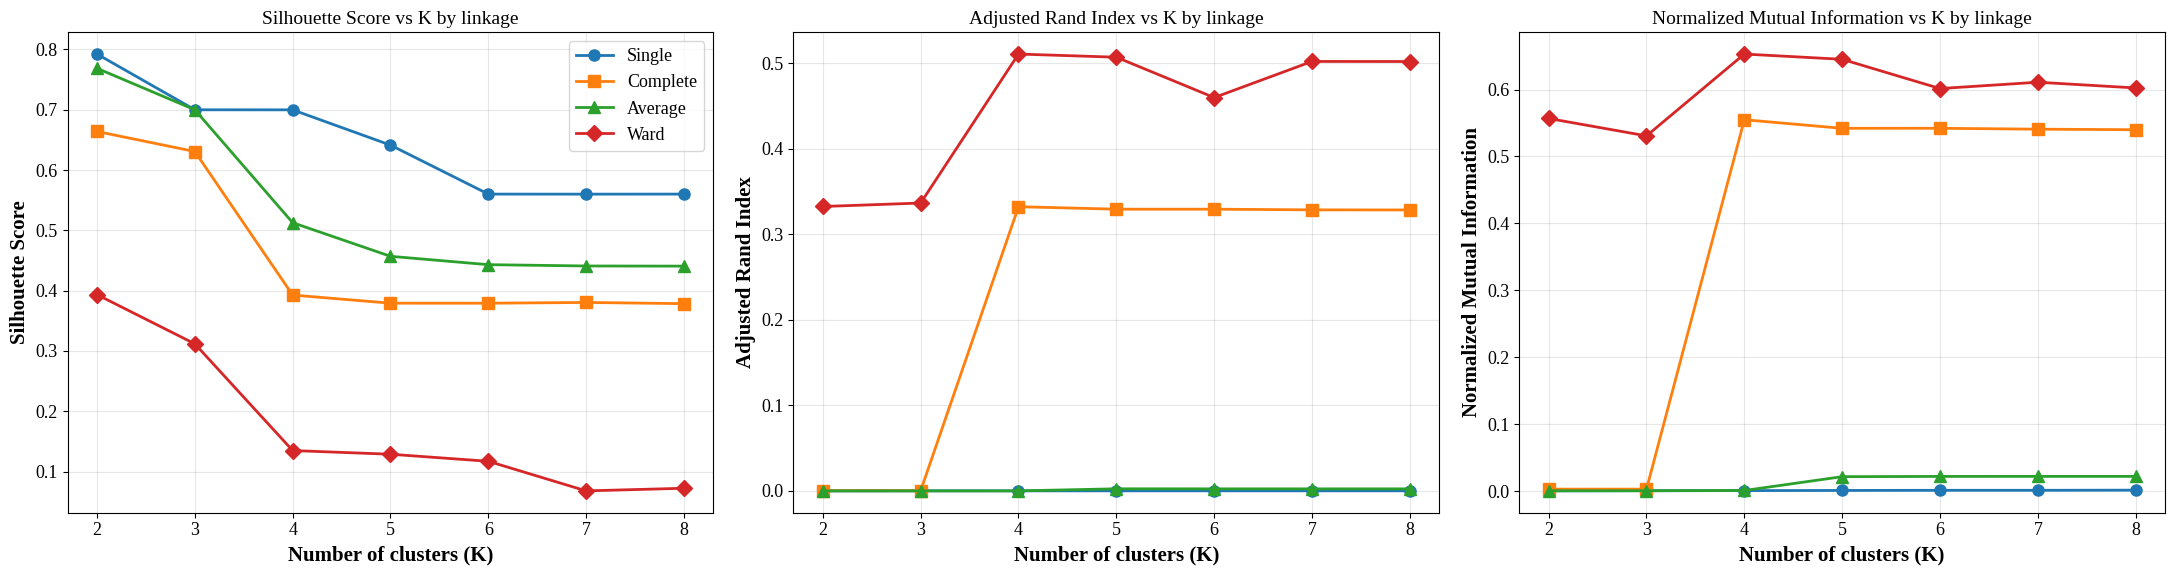

In [26]:
t4_ks = sorted({k_final, REF_K})
hac_df["_ord"] = hac_df["linkage"].map({m: i for i, m in enumerate(LINKAGES)})
table4 = hac_df[hac_df.K.isin(t4_ks)].sort_values(["K", "_ord"]).reset_index(drop=True)
table4 = table4[["linkage", "K", "clusters", "smallest_cluster", "largest_cluster", "Silhouette", "Davies-Bouldin",
                 "Calinski-Harabasz", "ARI", "NMI", "cophenetic_corr"]]
hac_df = hac_df.drop(columns="_ord")
save_table(table4, "table4_hierarchical_linkage_comparison")
display(table4.round(4))
print("\nSilhouette vs K for each linkage:")
display(hac_df.pivot(index="K", columns="linkage", values="Silhouette")[LINKAGES].round(4))

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (col, yl) in zip(axes, [("Silhouette", "Silhouette Score"), ("ARI", "Adjusted Rand Index"), ("NMI", "Normalized Mutual Information")]):
    for m, mk in zip(LINKAGES, ["o", "s", "^", "D"]):
        d = hac_df[hac_df.linkage == m]
        ax.plot(d.K, d[col], marker=mk, linewidth=2, markersize=8, label=m.capitalize())
    ax.set_xlabel("Number of clusters (K)"); ax.set_ylabel(yl); ax.set_xticks(K_RANGE); ax.grid(alpha=0.3)
    ax.set_title(f"{yl} vs K by linkage", fontsize=14)
axes[0].legend(fontsize=13)
plt.tight_layout(); save_fig(fig, "fig13_hac_linkage_metrics_vs_k"); plt.show()

### 9.3 Dendrograms

**Main dendrograms (complete dataset).** Drawing all 10,299 leaves is unreadable, so `truncate_mode="lastp"` collapses the tree to its last 30 merged clusters; each leaf shows the number of observations it contains, e.g. `(1234)`. The tree itself was built from **all 10,299 observations** – nothing is sampled. Dashed lines mark the heights at which the tree is cut to give the *K* values used in this study.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig14_dendrogram_ward_truncated.eps and .png


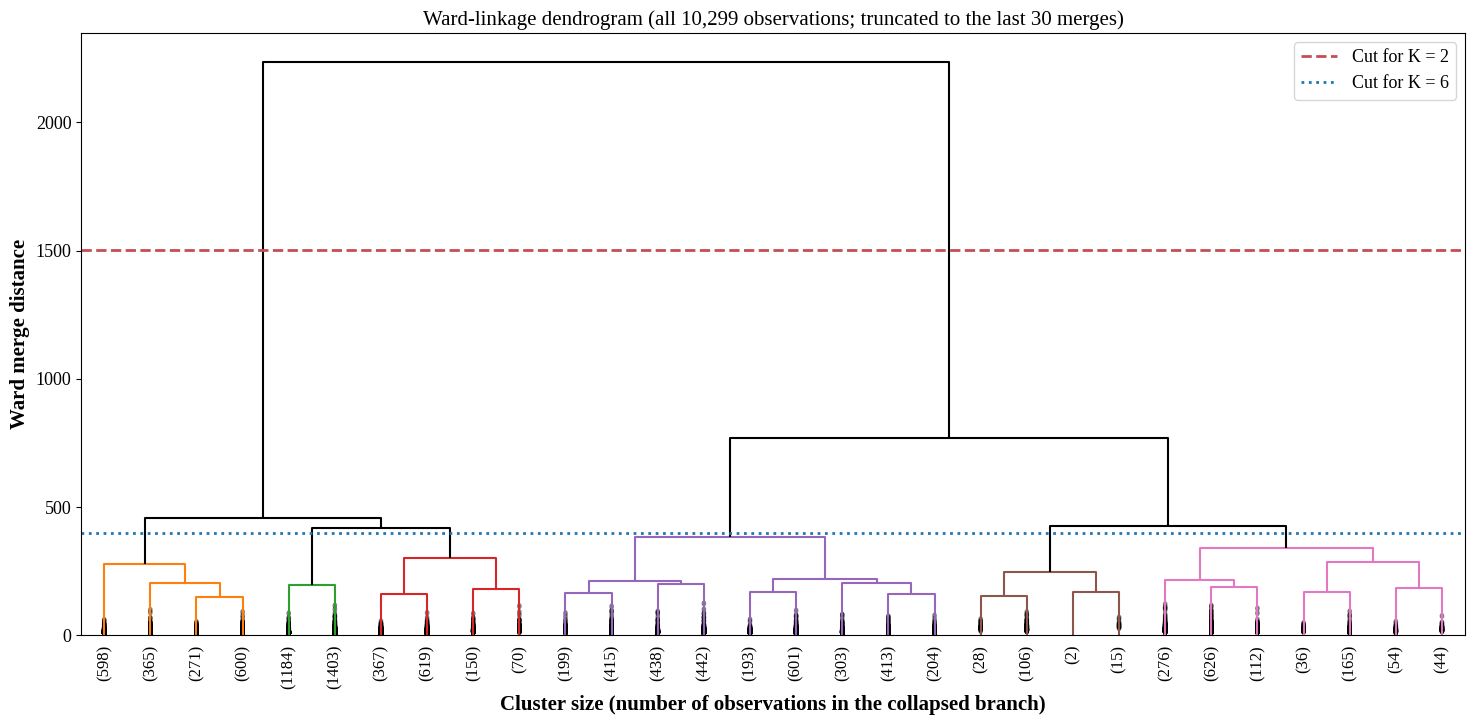

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig15_dendrograms_all_linkages.eps and .png


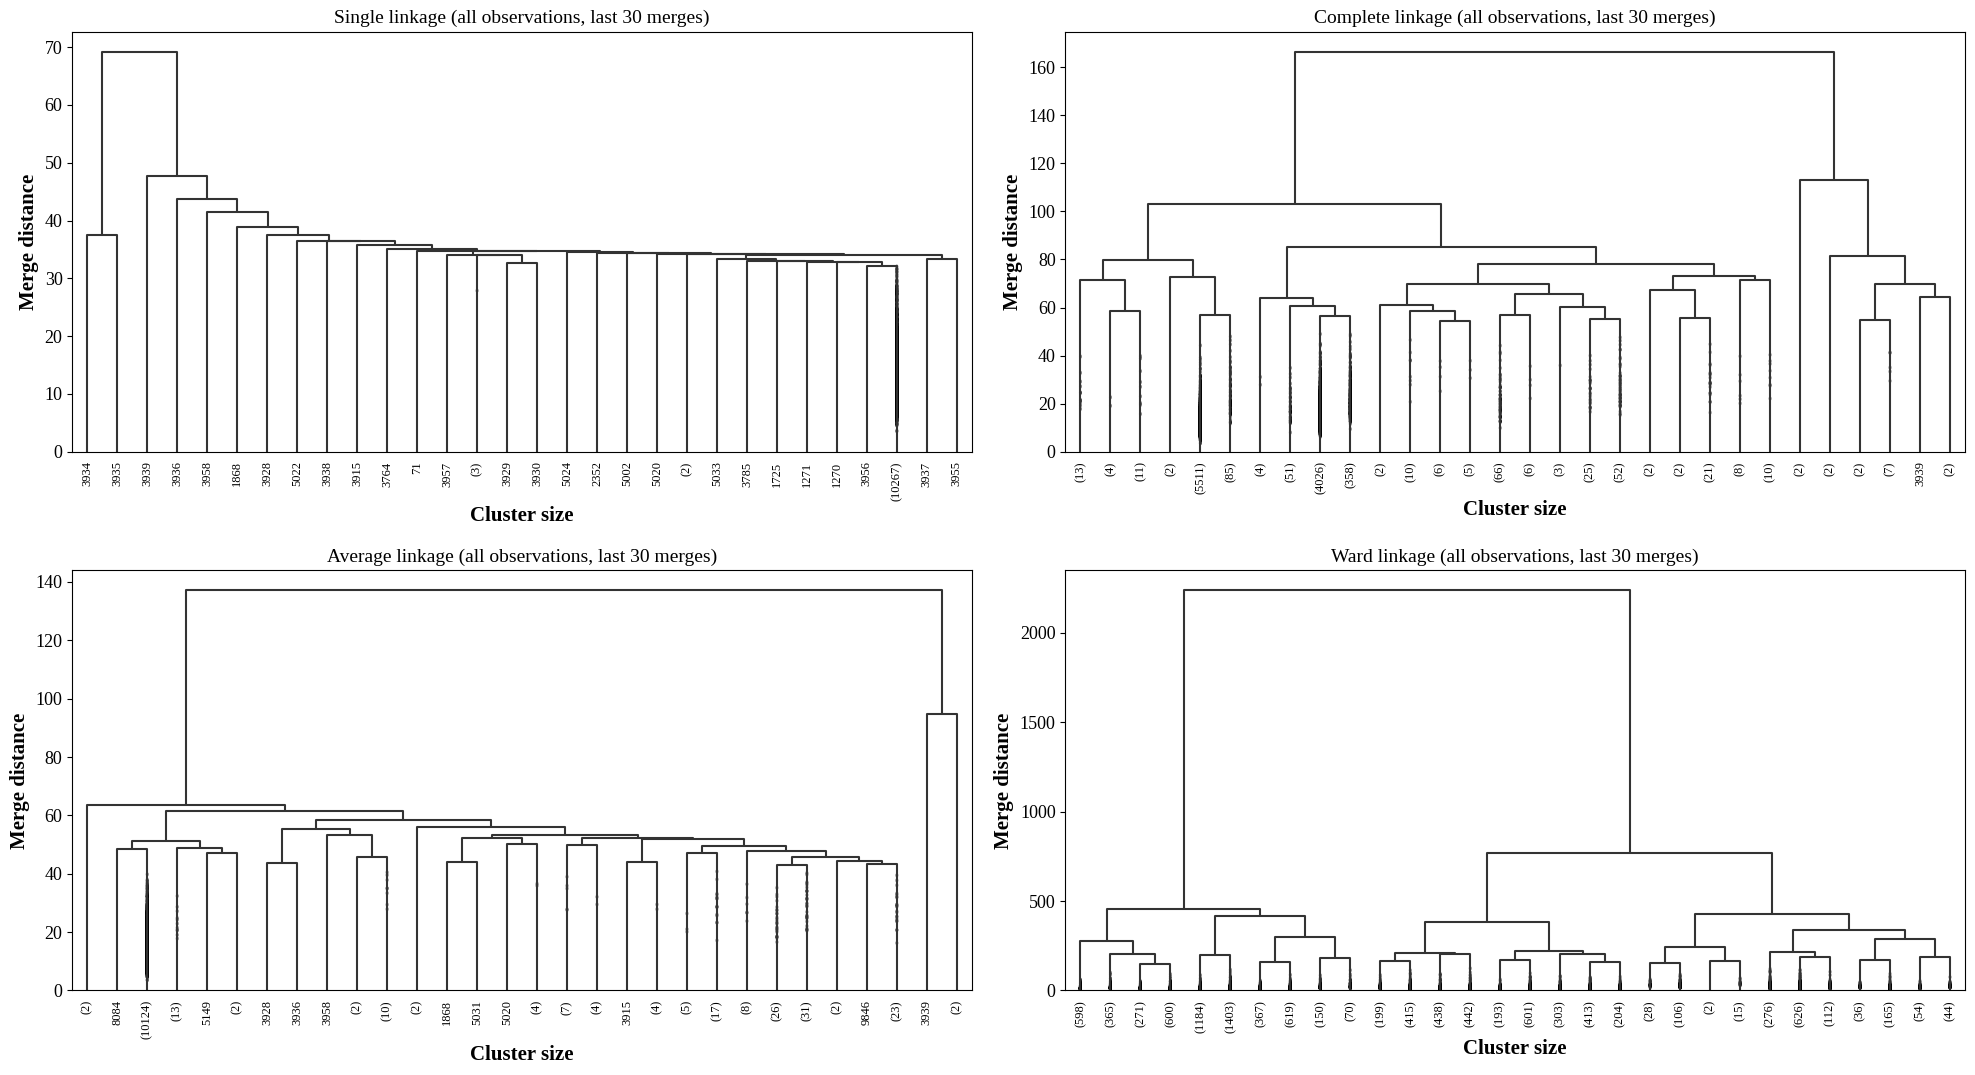

In [27]:
def cut_height(Z, K):
    """A horizontal cut at this height yields exactly K clusters (midpoint between the (K-1)-th and K-th last merges)."""
    return 0.5 * (Z[-(K - 1), 2] + Z[-K, 2]) if K >= 2 else np.nan

fig, ax = plt.subplots(figsize=(15, 7.5))
safe_dendrogram(Z_LINK["ward"], truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=12, show_contracted=True,
           color_threshold=cut_height(Z_LINK["ward"], REF_K), above_threshold_color="black", ax=ax)
for K, ls, c in [(k_final, "--", "#C44E52"), (REF_K, ":", "#1f77b4")]:
    ax.axhline(cut_height(Z_LINK["ward"], K), linestyle=ls, color=c, linewidth=2, label=f"Cut for K = {K}")
ax.set_title("Ward-linkage dendrogram (all 10,299 observations; truncated to the last 30 merges)")
ax.set_xlabel("Cluster size (number of observations in the collapsed branch)"); ax.set_ylabel("Ward merge distance")
ax.legend(fontsize=13)
plt.tight_layout(); save_fig(fig, "fig14_dendrogram_ward_truncated"); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(20, 11))
for ax, m in zip(axes.ravel(), LINKAGES):
    safe_dendrogram(Z_LINK[m], truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9, show_contracted=True, color_threshold=0,
               above_threshold_color="#333333", ax=ax)
    ax.set_title(f"{m.capitalize()} linkage (all observations, last 30 merges)", fontsize=14)
    ax.set_xlabel("Cluster size"); ax.set_ylabel("Merge distance")
plt.tight_layout(); save_fig(fig, "fig15_dendrograms_all_linkages"); plt.show()

**Supplementary dendrogram (random sample – for visualisation only).** To let the *individual* leaves and the activity composition be seen, a random sample of **300 of the 10,299 observations** (`RandomState(42)`, drawn without replacement) is clustered with Ward linkage and drawn in full. The coloured strip under the leaves shows the true activity of each sampled window (ground truth used **only for colouring**). This sample tree is a visual aid; **all reported metrics come from the full-data clustering above.**

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig16_dendrogram_ward_sample300.eps and .png


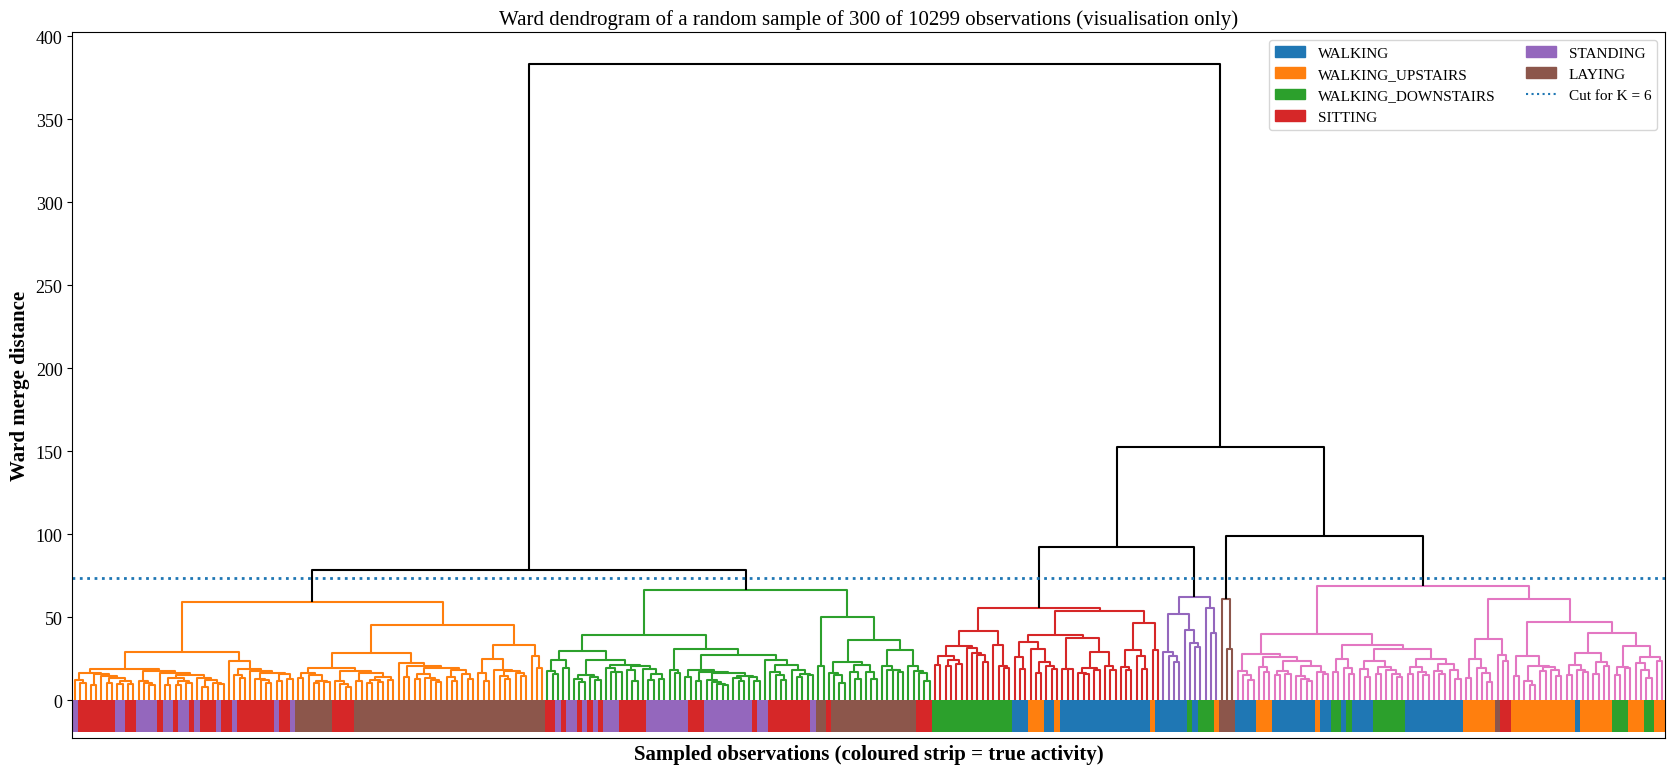

In [28]:
SAMPLE_N = 300
rs = np.random.RandomState(RANDOM_STATE)
samp_idx = np.sort(rs.choice(N, size=SAMPLE_N, replace=False))
Zs = linkage(X_scaled[samp_idx], method="ward")
fig, ax = plt.subplots(figsize=(17, 8))
dd = safe_dendrogram(Zs, no_labels=True, color_threshold=cut_height(Zs, REF_K), above_threshold_color="black", ax=ax)
leaf_act = y_true[samp_idx][dd["leaves"]]
xs = 5 + 10 * np.arange(SAMPLE_N)
strip_h = 0.05 * Zs[-1, 2]
ax.bar(xs, -strip_h, width=10, bottom=0, color=[ACT_COLORS[ACT_NAMES[a]] for a in leaf_act], edgecolor="none")
ax.set_ylim(-strip_h * 1.2, Zs[-1, 2] * 1.05)
ax.axhline(cut_height(Zs, REF_K), linestyle=":", color="#1f77b4", linewidth=2)
ax.set_title(f"Ward dendrogram of a random sample of {SAMPLE_N} of {N} observations (visualisation only)")
ax.set_xlabel(f"Sampled observations (coloured strip = true activity)"); ax.set_ylabel("Ward merge distance")
ax.legend(handles=[Patch(color=ACT_COLORS[a], label=a) for a in ACT_NAMES] +
                  [Line2D([0], [0], color="#1f77b4", linestyle=":", label=f"Cut for K = {REF_K}")], fontsize=11, ncol=2, loc="upper right")
plt.tight_layout(); save_fig(fig, "fig16_dendrogram_ward_sample300"); plt.show()
RESULTS["dendrogram_sample"] = {"n_sample": SAMPLE_N, "random_state": RANDOM_STATE, "n_total": int(N)}

### 9.4 HAC cluster visualisation (PCA)

Effect of the linkage on the cluster shapes for the same *K* = 6 (top), and the Ward solution at the selected *K* (bottom-left).

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig17_hac_pca_all_linkages_K6.eps and .png


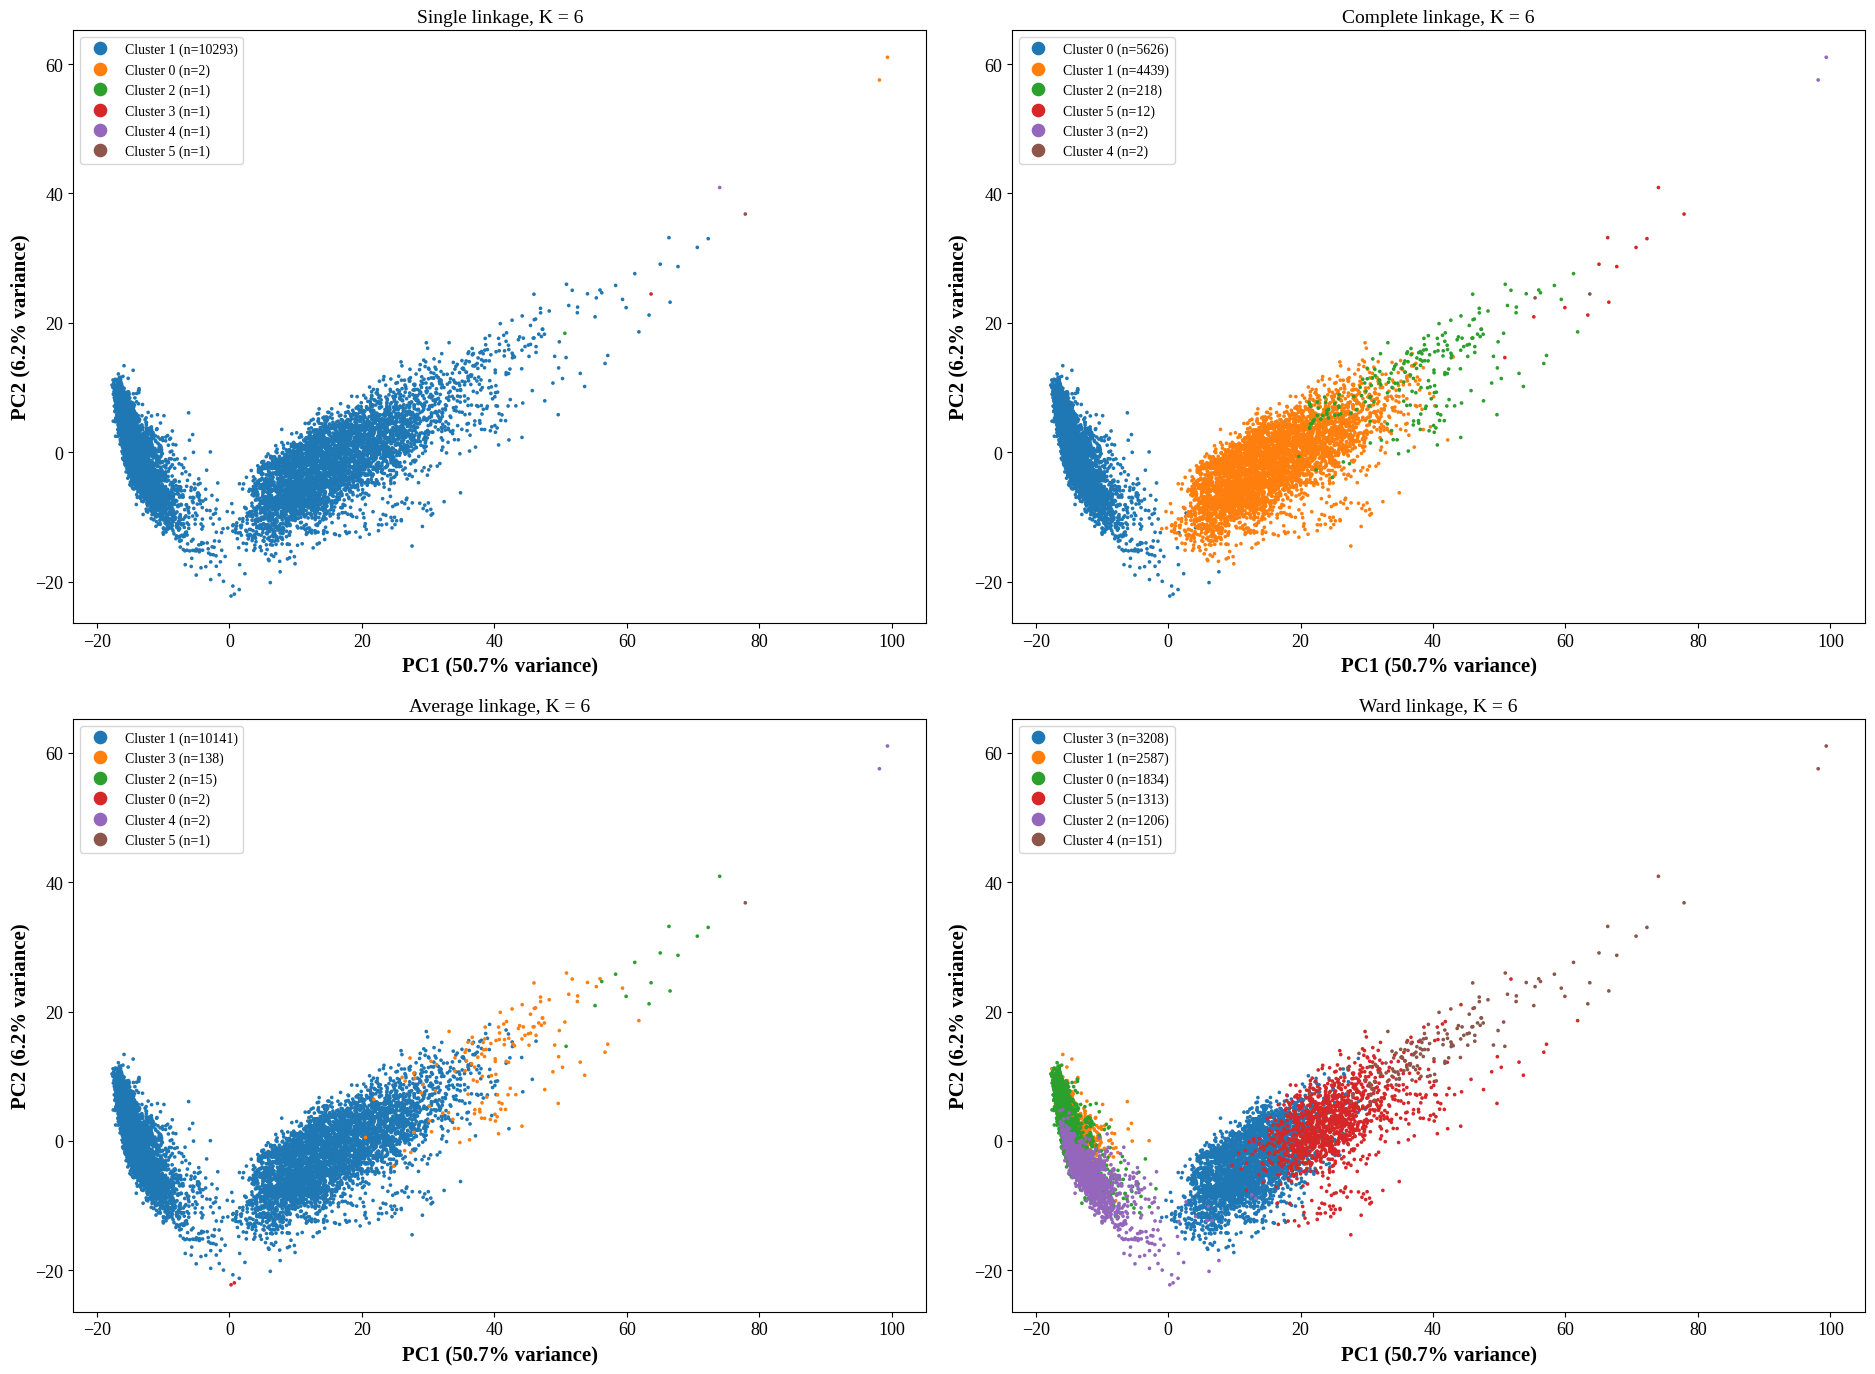

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig18_hac_ward_pca_clusters.eps and .png


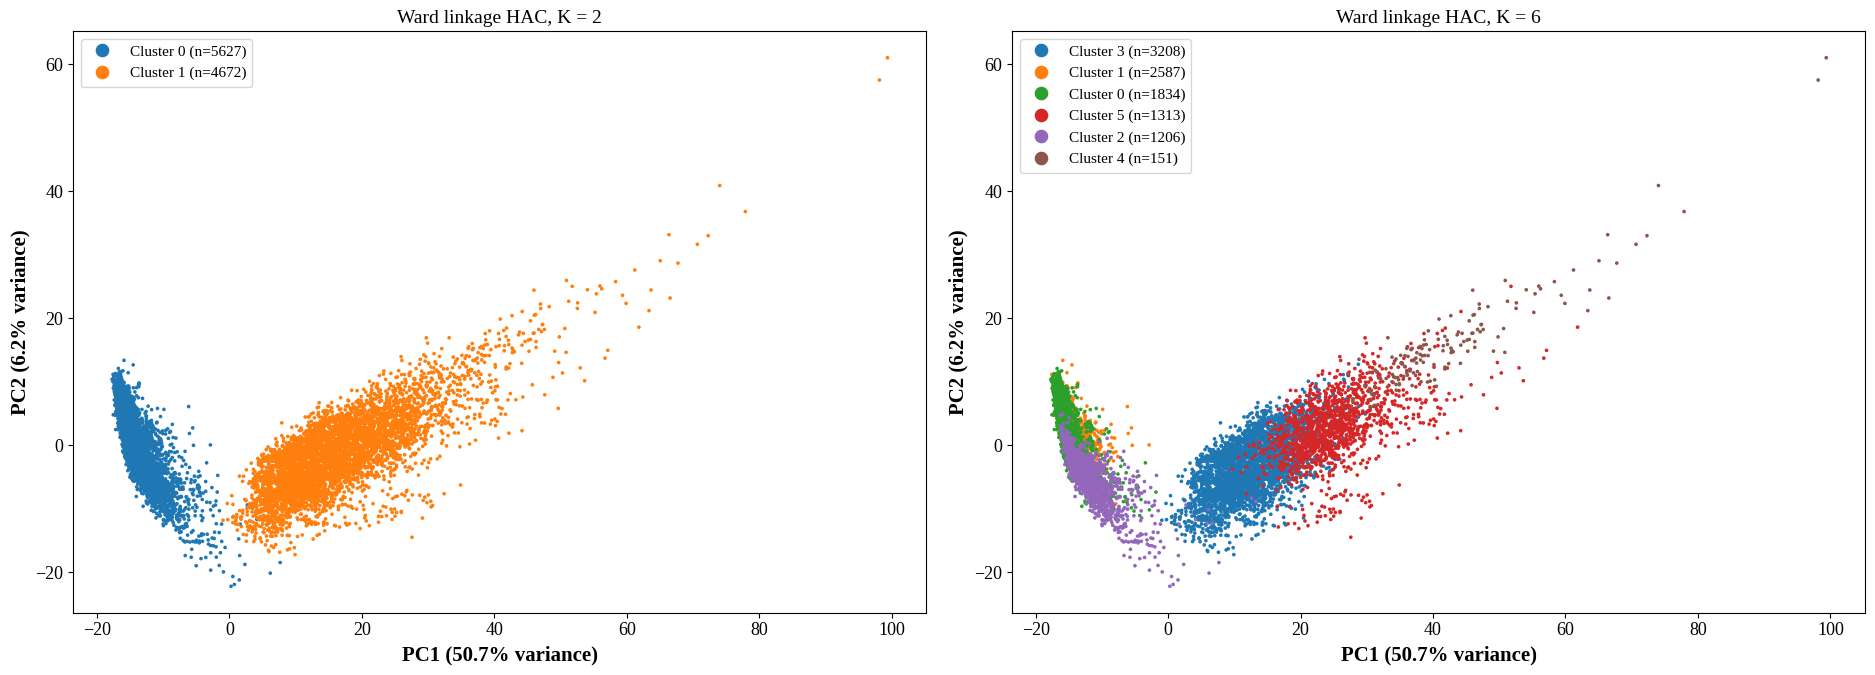

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(19, 14))
for ax, m in zip(axes.ravel(), LINKAGES):
    plot_clusters(ax, Z2, HAC_LABELS[(m, REF_K)], f"{m.capitalize()} linkage, K = {REF_K}", legend_fs=10)
plt.tight_layout(); save_fig(fig, "fig17_hac_pca_all_linkages_K6"); plt.show()

hac_view_ks = sorted({k_final, REF_K})
fig, axes = plt.subplots(1, len(hac_view_ks), figsize=(9.5 * len(hac_view_ks), 7))
for ax, K in zip(np.atleast_1d(axes), hac_view_ks):
    plot_clusters(ax, Z2, HAC_LABELS[("ward", K)], f"Ward linkage HAC, K = {K}", legend_fs=11)
plt.tight_layout(); save_fig(fig, "fig18_hac_ward_pca_clusters"); plt.show()

## 10. Supplementary Visualisation – t-SNE

PCA is a linear projection and cannot show every cluster boundary. As a second, non-linear view, t-SNE (perplexity 30, `random_state=42`, PCA initialisation) is applied to the first 50 principal components of the standardised data (a standard speed-up). t-SNE is used **for display only**: distances in a t-SNE map are not metrically meaningful, and no metric in this notebook is computed on it.

In [30]:
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=RANDOM_STATE)
T2 = tsne.fit_transform(Z_all[:, :50])
print(f"t-SNE finished in {time.time()-t0:.0f}s; final KL divergence = {tsne.kl_divergence_:.4f}")
RESULTS["tsne"] = {"perplexity": 30, "input_pcs": 50, "kl_divergence": float(tsne.kl_divergence_), "seconds": float(time.time() - t0)}

t-SNE finished in 67s; final KL divergence = 1.7756


## 11. Final Comparison of the Three Algorithms

The compared models are: K-Means at the selected *k* and at the reference *k* = 6; the DBSCAN configuration selected in §8.4; and Ward-linkage HAC at the same two *K* values. Ward is used as the HAC representative because it is the linkage prescribed by the experiment sheet; the other linkages are compared in Table 4.

In [31]:
FINAL = {}   # key -> dict(algorithm, params, labels)
for k in sorted({k_final, REF_K}):
    FINAL[f"K-Means (k={k})"] = dict(algorithm="K-Means", params=f"k={k}, n_init=10, random_state=42", labels=KM_LABELS[k])
FINAL[f"DBSCAN (eps={BEST_EPS}, min_samples={BEST_MS})"] = dict(algorithm="DBSCAN", params=f"eps={BEST_EPS}, min_samples={BEST_MS}", labels=db_best_labels)
for K in sorted({k_final, REF_K}):
    FINAL[f"HAC-Ward (K={K})"] = dict(algorithm="Hierarchical (Ward)", params=f"linkage=ward, n_clusters={K}", labels=HAC_LABELS[("ward", K)])

rows2 = []
for name, d in FINAL.items():
    ev = evaluate_clustering(X_scaled, d["labels"], y_true)
    rows2.append({"Model": name, "Algorithm": d["algorithm"], "Parameters": d["params"], "Clusters": ev["clusters"], "Noise": ev["noise"],
                  "Silhouette": ev["Silhouette"], "Davies-Bouldin": ev["Davies-Bouldin"], "Calinski-Harabasz": ev["Calinski-Harabasz"],
                  "ARI": ev["ARI"], "NMI": ev["NMI"], "ARI_core": ev["ARI_core"], "NMI_core": ev["NMI_core"]})
table2 = pd.DataFrame(rows2)

# Consistency checks against the tables produced earlier (values must be identical)
for _, r in table2.iterrows():
    if r.Algorithm == "K-Means":
        k = int(r.Model.split("=")[1].rstrip(")")); ref = km_tbl[km_tbl.k == k].iloc[0]
        assert np.isclose(r.Silhouette, ref.Silhouette) and np.isclose(r.ARI, ref.ARI)
    elif r.Algorithm == "DBSCAN":
        ref = grid_df[(grid_df.eps == BEST_EPS) & (grid_df.min_samples == BEST_MS)].iloc[0]
        assert np.isclose(r.Silhouette, ref.Silhouette) and np.isclose(r.ARI, ref.ARI) and int(r.Noise) == int(ref.noise)
    else:
        K = int(r.Model.split("=")[1].rstrip(")")); ref = hac_df[(hac_df.linkage == "ward") & (hac_df.K == K)].iloc[0]
        assert np.isclose(r.Silhouette, ref.Silhouette) and np.isclose(r.ARI, ref.ARI)
print("Consistency checks passed: Table 2 values equal the values in Tables 1, 3 and 4.")

save_table(table2, "table2_final_clustering_comparison")
print("\nTable 2 - Final clustering comparison")
display(table2.drop(columns=["Model"]).round(4))

Consistency checks passed: Table 2 values equal the values in Tables 1, 3 and 4.
Saved tables/table2_final_clustering_comparison.csv  (5 rows)

Table 2 - Final clustering comparison


,Algorithm,Parameters,Clusters,Noise,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,ARI_core,NMI_core
0,K-Means,"k=2, n_init=10, random_state=42",2,0,0.3937,1.0707,7880.8139,0.3296,0.5455,0.3296,0.5455
1,K-Means,"k=6, n_init=10, random_state=42",6,0,0.1099,2.3836,2556.5419,0.4196,0.5593,0.4196,0.5593
2,DBSCAN,"eps=14, min_samples=50",2,4126,0.4077,1.0572,3343.3705,0.2574,0.4051,0.2377,0.4772
3,Hierarchical (Ward),"linkage=ward, n_clusters=2",2,0,0.3934,1.0717,7859.7554,0.3325,0.5568,0.3325,0.5568
4,Hierarchical (Ward),"linkage=ward, n_clusters=6",6,0,0.1170,2.4820,2349.6677,0.4599,0.6015,0.4599,0.6015


### 11.1 Table 5 – Cluster size distribution

Saved tables/table5_cluster_size_distribution.csv  (19 rows)


,Model,Cluster,Size,Percent
0,K-Means (k=2),C0,5620,54.57
1,K-Means (k=2),C1,4679,45.43
2,K-Means (k=6),C0,2638,25.61
3,K-Means (k=6),C1,307,2.98
4,K-Means (k=6),C2,1920,18.64
5,K-Means (k=6),C3,2449,23.78
6,K-Means (k=6),C4,1338,12.99
7,K-Means (k=6),C5,1647,15.99
8,"DBSCAN (eps=14, min_samples=50)",Noise,4126,40.06
9,"DBSCAN (eps=14, min_samples=50)",C0,5028,48.82


Saved figures/fig19_cluster_size_distribution.eps and .png


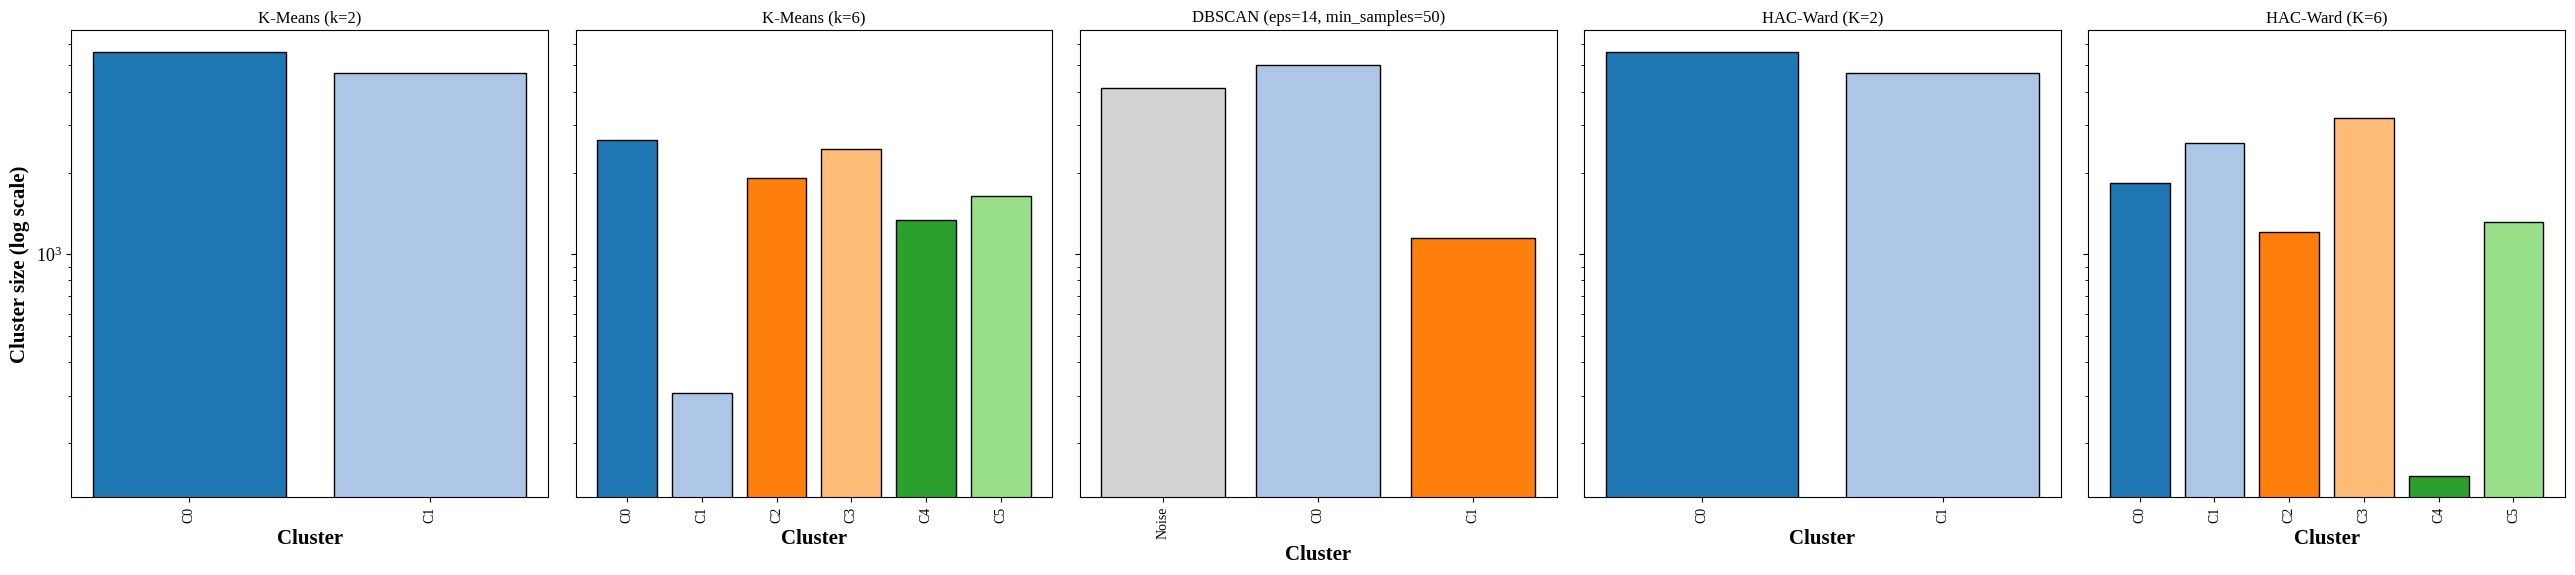

In [32]:
t5 = []
for name, d in FINAL.items():
    lab = np.asarray(d["labels"])
    for u in np.unique(lab):
        n_u = int((lab == u).sum())
        t5.append({"Model": name, "Cluster": "Noise" if u == -1 else f"C{u}", "Size": n_u, "Percent": 100 * n_u / N})
table5 = pd.DataFrame(t5)
save_table(table5, "table5_cluster_size_distribution")
with pd.option_context("display.max_rows", 200):
    display(table5.round(2))

n_models = len(FINAL)
fig, axes = plt.subplots(1, n_models, figsize=(5.2 * n_models, 6), sharey=True)
for ax, (name, d) in zip(axes, FINAL.items()):
    lab = np.asarray(d["labels"]); us = np.unique(lab)
    sz = [int((lab == u).sum()) for u in us]; nm = ["Noise" if u == -1 else f"C{u}" for u in us]
    cols = ["lightgray" if u == -1 else plt.get_cmap("tab20")(i % 20) for i, u in enumerate(us)]
    ax.bar(range(len(us)), sz, color=cols, edgecolor="black")
    ax.set_yscale("log"); ax.set_title(name, fontsize=12)
    ax.set_xticks(range(len(us))); ax.set_xticklabels(nm, rotation=90, fontsize=10)
    ax.set_xlabel("Cluster")
axes[0].set_ylabel("Cluster size (log scale)")
plt.tight_layout(); save_fig(fig, "fig19_cluster_size_distribution"); plt.show()

### 11.2 Evaluation-metric comparison

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig20_metric_comparison.eps and .png


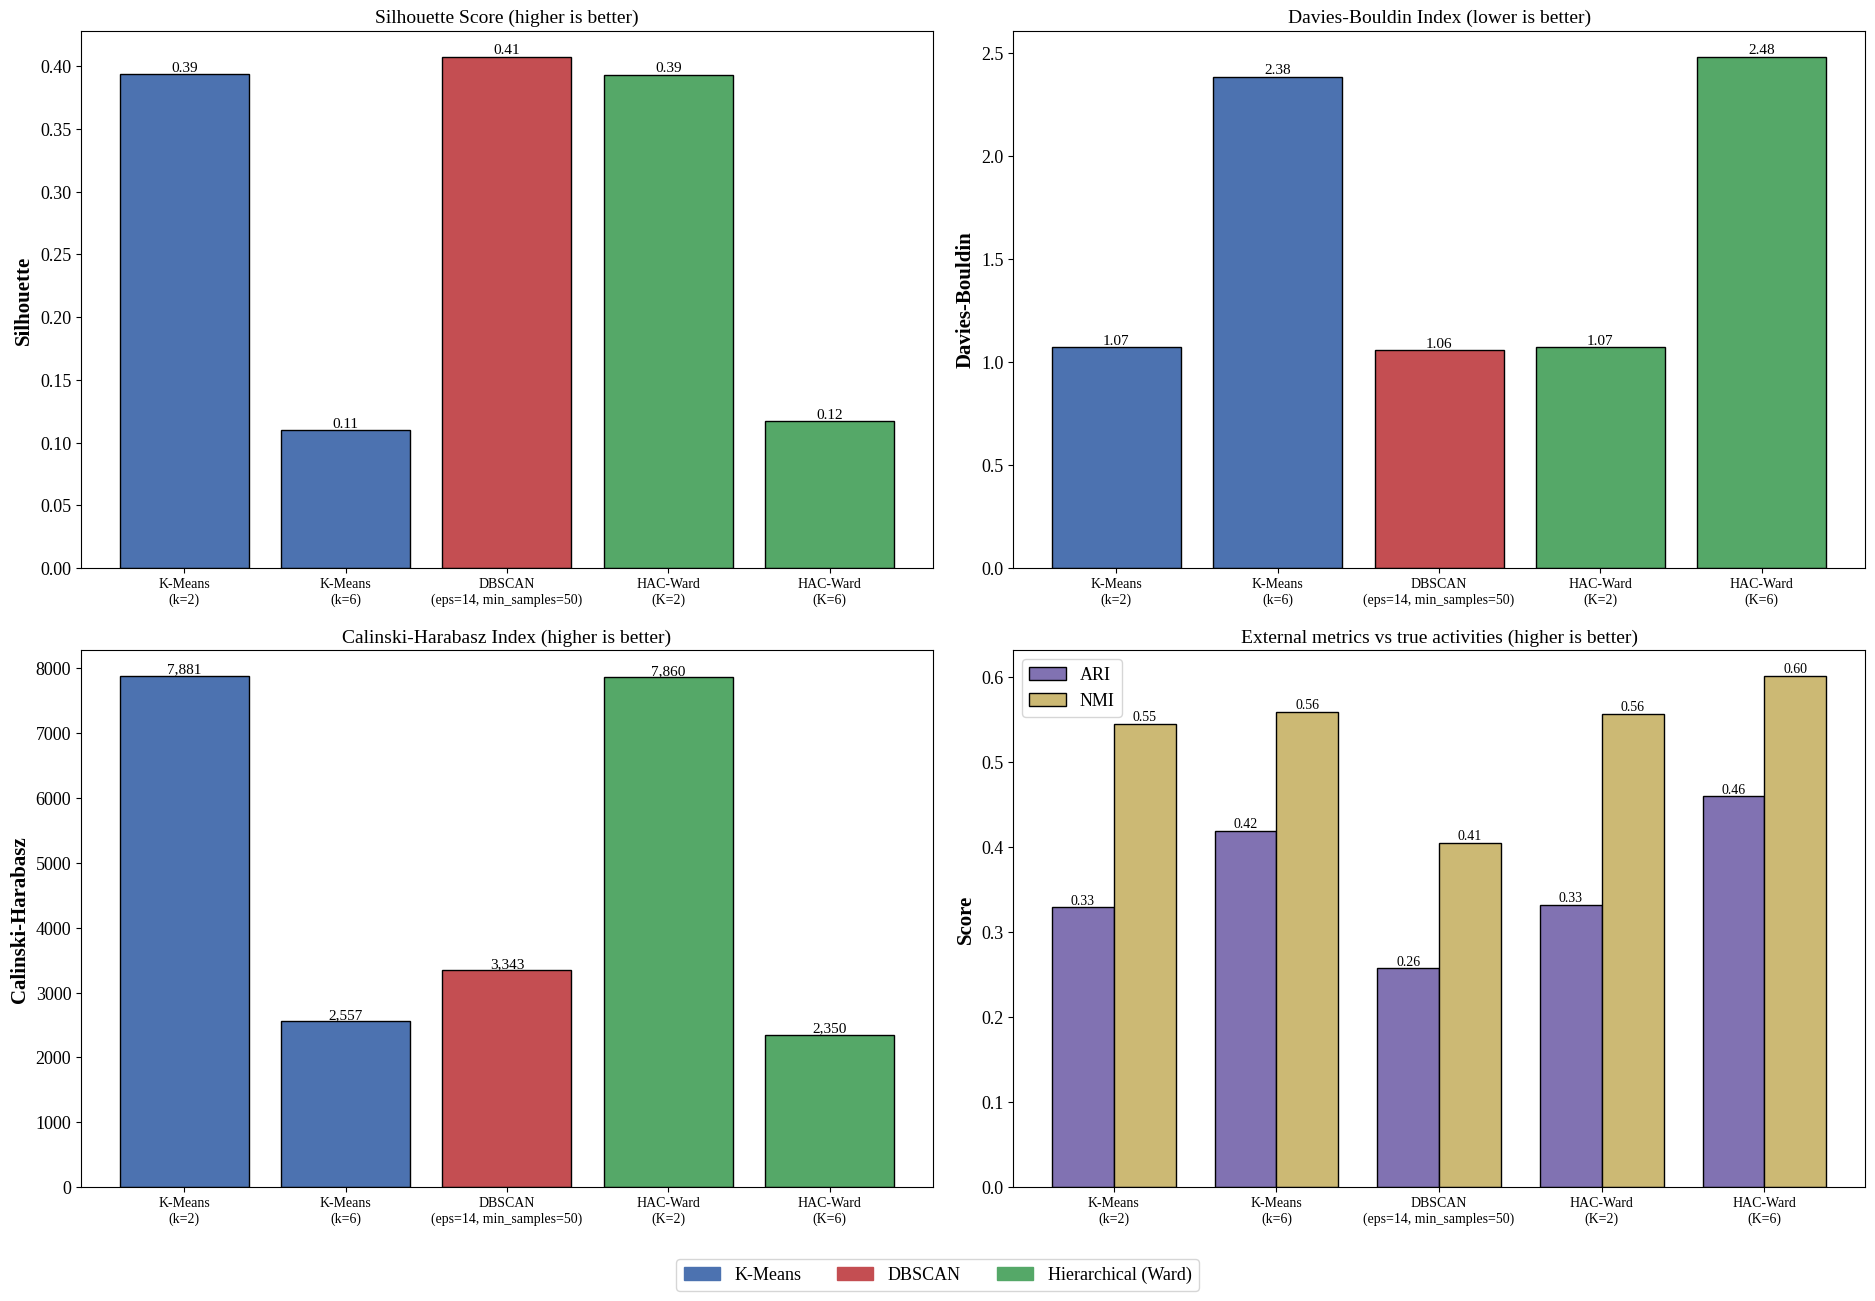

In [33]:
labels_short = [n.replace(" (", "\n(") for n in table2["Model"]]
xpos = np.arange(len(table2))
palette = {"K-Means": "#4C72B0", "DBSCAN": "#C44E52", "Hierarchical (Ward)": "#55A868"}
bar_cols = [palette[a] for a in table2["Algorithm"]]

fig, axes = plt.subplots(2, 2, figsize=(19, 13))
for ax, (col, ttl) in zip(axes.ravel()[:3], [("Silhouette", "Silhouette Score (higher is better)"),
                                            ("Davies-Bouldin", "Davies-Bouldin Index (lower is better)"),
                                            ("Calinski-Harabasz", "Calinski-Harabasz Index (higher is better)")]):
    ax.bar(xpos, table2[col], color=bar_cols, edgecolor="black")
    for x, v in zip(xpos, table2[col]):
        ax.text(x, v, "n/a" if np.isnan(v) else f"{v:.2f}" if col != "Calinski-Harabasz" else f"{v:,.0f}", ha="center", va="bottom", fontsize=11)
    ax.set_title(ttl, fontsize=14); ax.set_xticks(xpos); ax.set_xticklabels(labels_short, fontsize=10, rotation=0)
    ax.set_ylabel(col)
ax = axes[1, 1]; w = 0.38
ax.bar(xpos - w / 2, table2["ARI"], w, label="ARI", color="#8172B2", edgecolor="black")
ax.bar(xpos + w / 2, table2["NMI"], w, label="NMI", color="#CCB974", edgecolor="black")
for x, a, b in zip(xpos, table2["ARI"], table2["NMI"]):
    ax.text(x - w / 2, a, f"{a:.2f}", ha="center", va="bottom", fontsize=10); ax.text(x + w / 2, b, f"{b:.2f}", ha="center", va="bottom", fontsize=10)
ax.set_title("External metrics vs true activities (higher is better)", fontsize=14)
ax.set_xticks(xpos); ax.set_xticklabels(labels_short, fontsize=10); ax.set_ylabel("Score"); ax.legend(fontsize=13)
handles = [Patch(color=c, label=a) for a, c in palette.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=13, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout(rect=(0, 0.03, 1, 1)); save_fig(fig, "fig20_metric_comparison"); plt.show()

### 11.3 Side-by-side cluster maps (PCA and t-SNE)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig21_side_by_side_pca.eps and .png


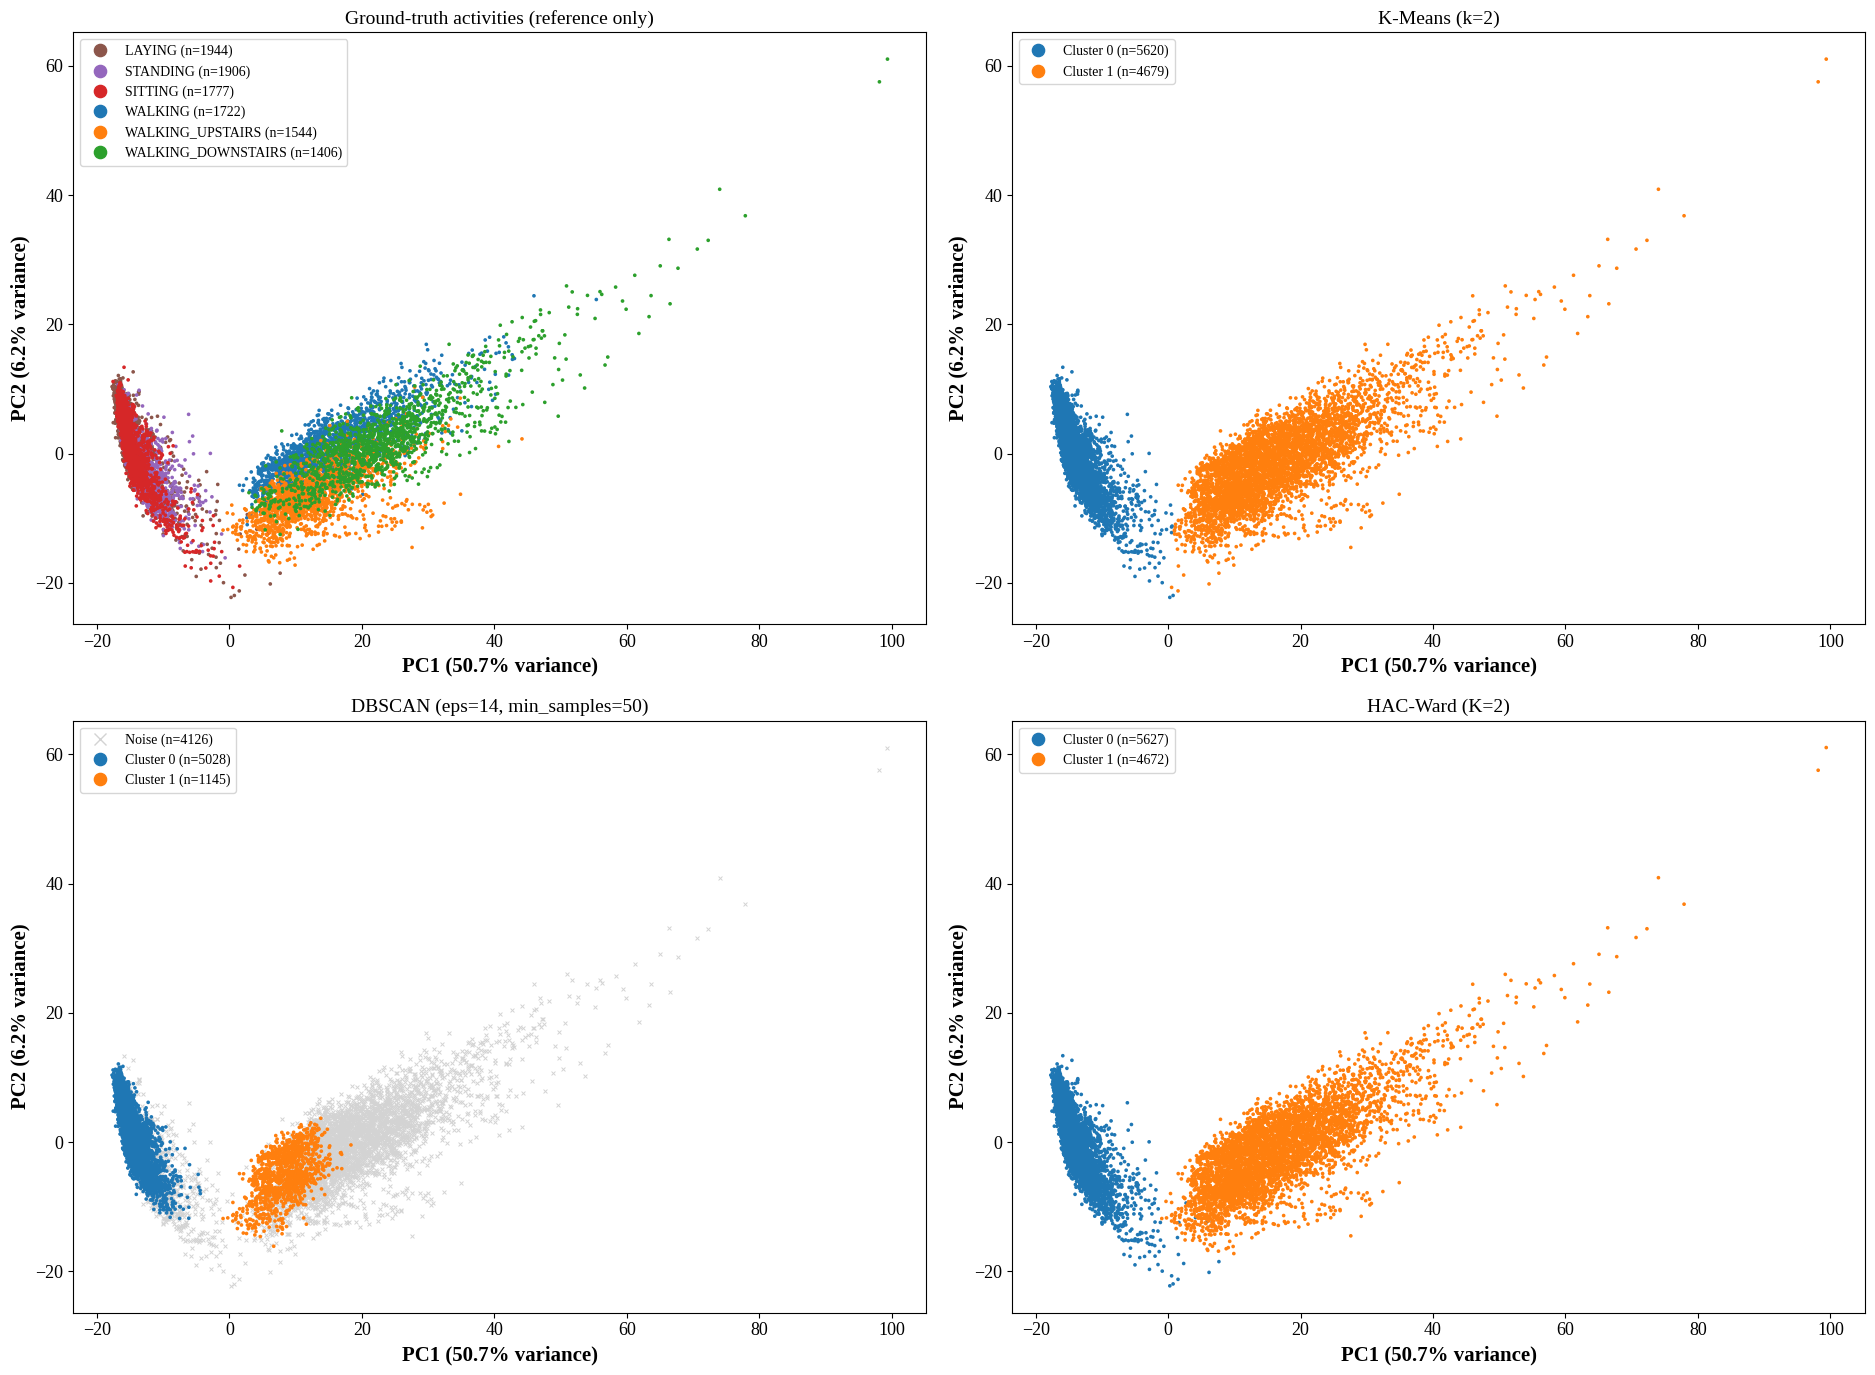

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figures/fig22_side_by_side_tsne.eps and .png


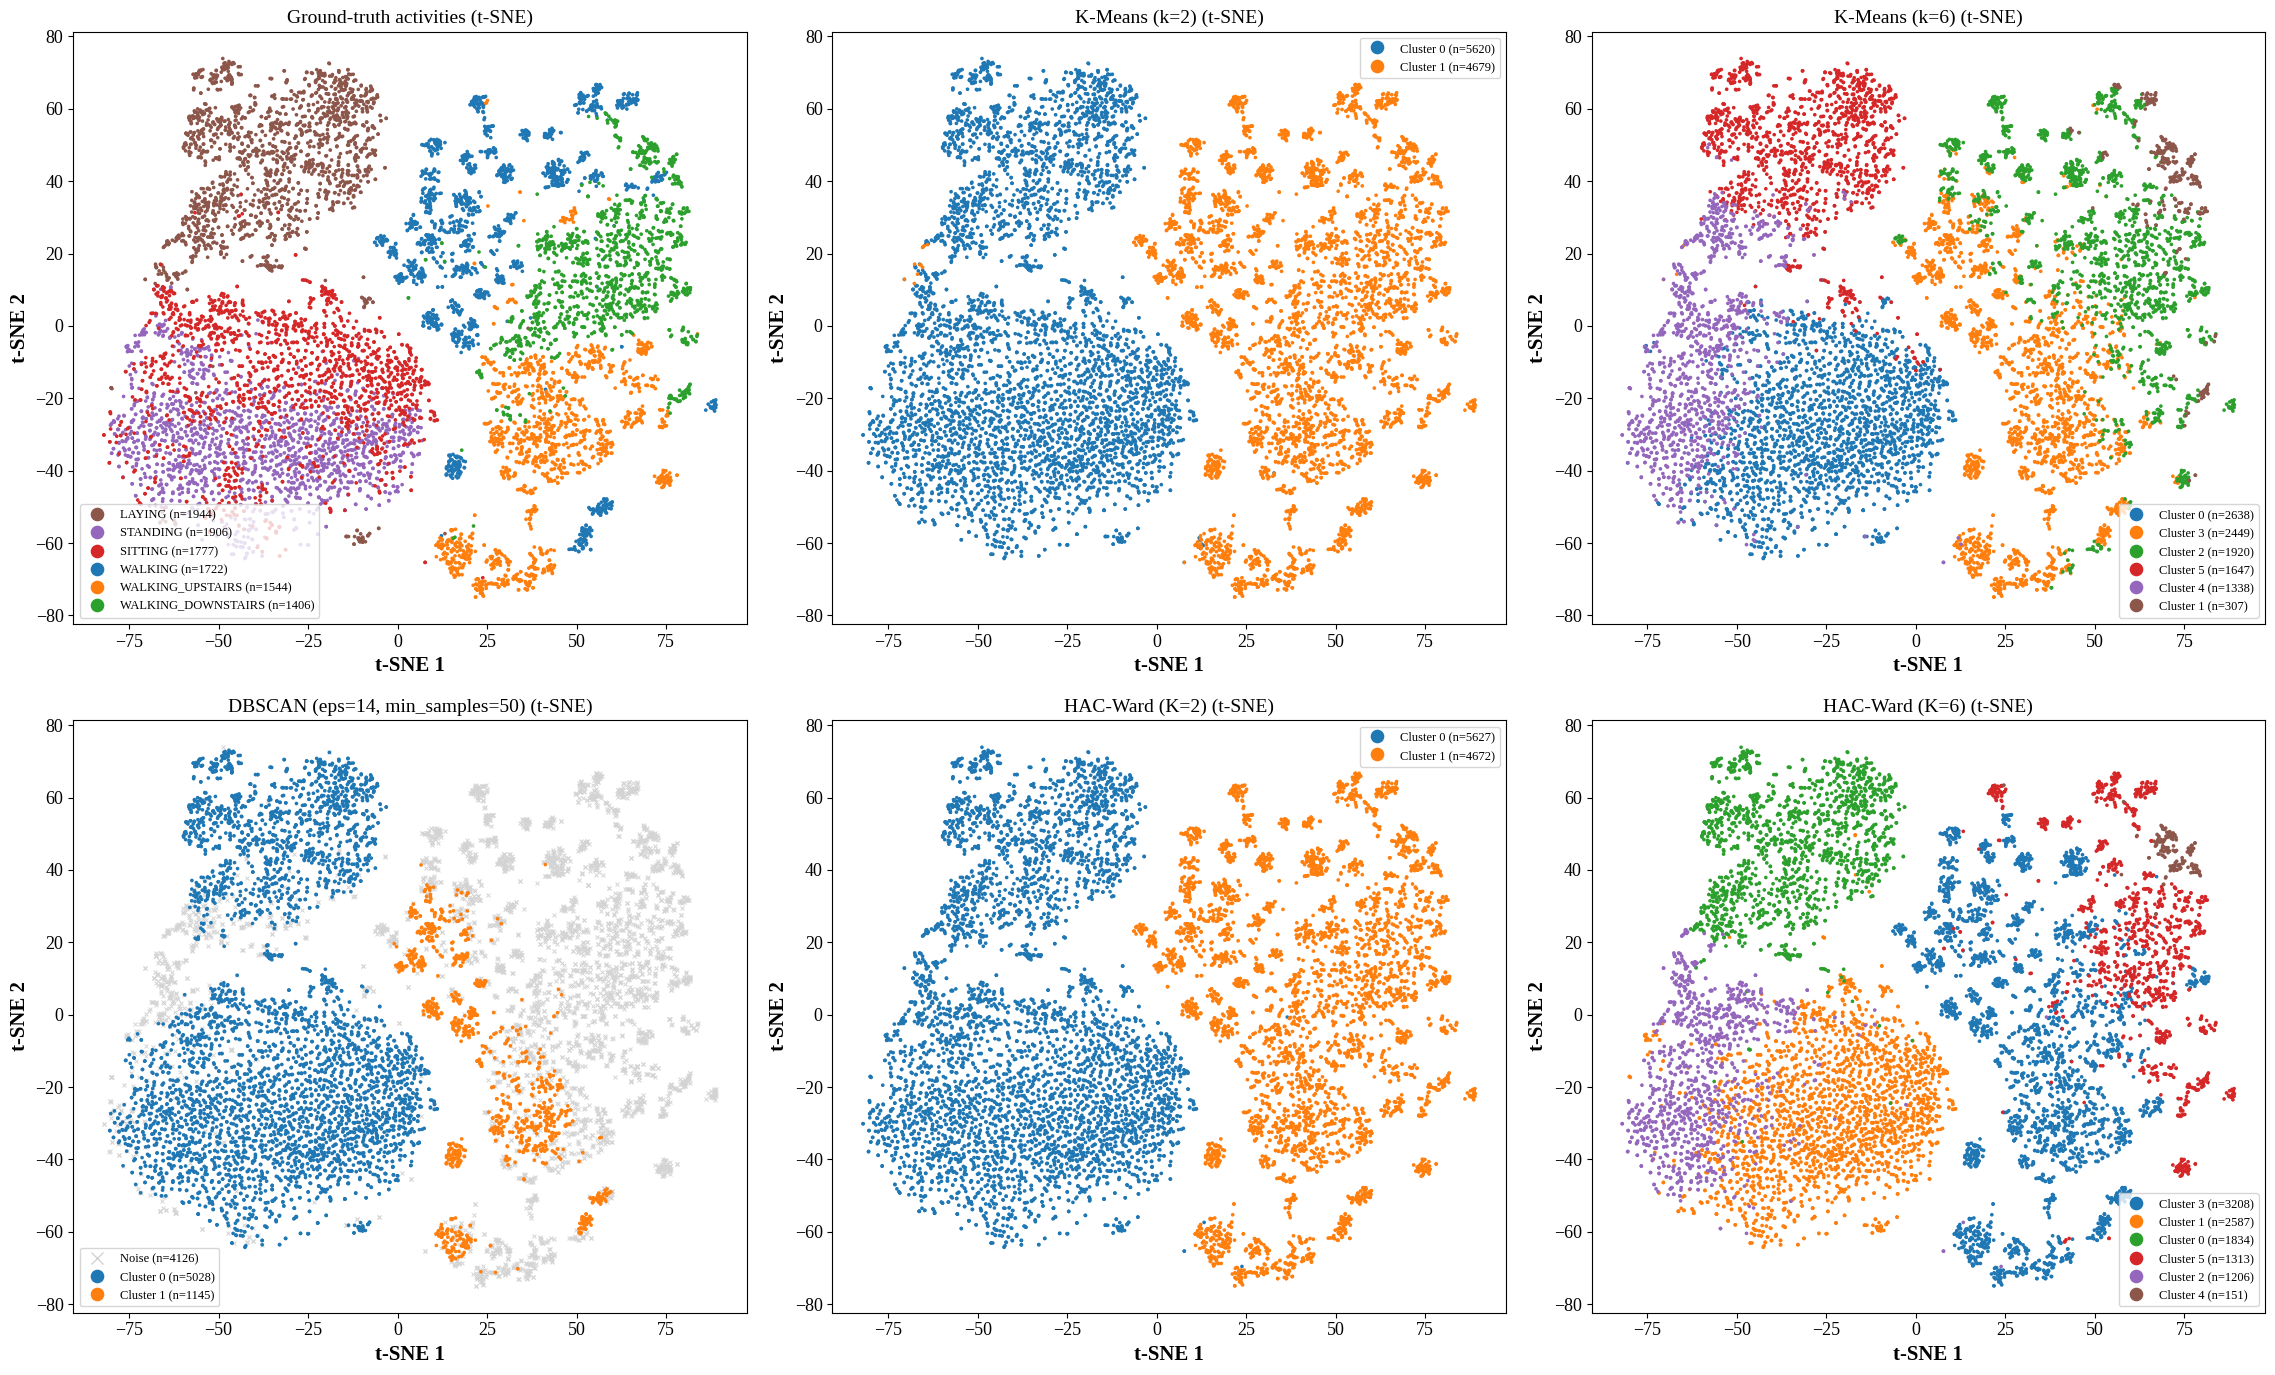

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(19, 14))
plot_clusters(axes[0, 0], Z2, y_true, "Ground-truth activities (reference only)", names=dict(enumerate(ACT_NAMES)),
              colors={i: ACT_COLORS[n] for i, n in enumerate(ACT_NAMES)}, legend_fs=10)
side = [f"K-Means (k={k_final})", f"DBSCAN (eps={BEST_EPS}, min_samples={BEST_MS})", f"HAC-Ward (K={k_final})"]
for ax, key in zip([axes[0, 1], axes[1, 0], axes[1, 1]], side):
    plot_clusters(ax, Z2, FINAL[key]["labels"], key, legend_fs=10)
plt.tight_layout(); save_fig(fig, "fig21_side_by_side_pca"); plt.show()

tsne_keys = list(FINAL.keys())
fig, axes = plt.subplots(2, 3, figsize=(23, 14))
plot_clusters(axes[0, 0], T2, y_true, "Ground-truth activities (t-SNE)", names=dict(enumerate(ACT_NAMES)),
              colors={i: ACT_COLORS[n] for i, n in enumerate(ACT_NAMES)}, legend_fs=9, xl="t-SNE 1", yl="t-SNE 2")
for ax, key in zip(axes.ravel()[1:], tsne_keys):
    plot_clusters(ax, T2, FINAL[key]["labels"], f"{key} (t-SNE)", legend_fs=9, xl="t-SNE 1", yl="t-SNE 2")
for ax in axes.ravel()[1 + len(tsne_keys):]:
    ax.axis("off")
plt.tight_layout(); save_fig(fig, "fig22_side_by_side_tsne"); plt.show()

### 11.4 Cluster-vs-activity contingency tables (optional confusion matrices)

Rows are clusters, columns are true activities; each cell counts windows. The mapping cluster → activity is read off the table (no assignment is forced), so it also shows *which activities are merged inside one cluster*.

Saved figures/fig23_contingency_selected_k.eps and .png


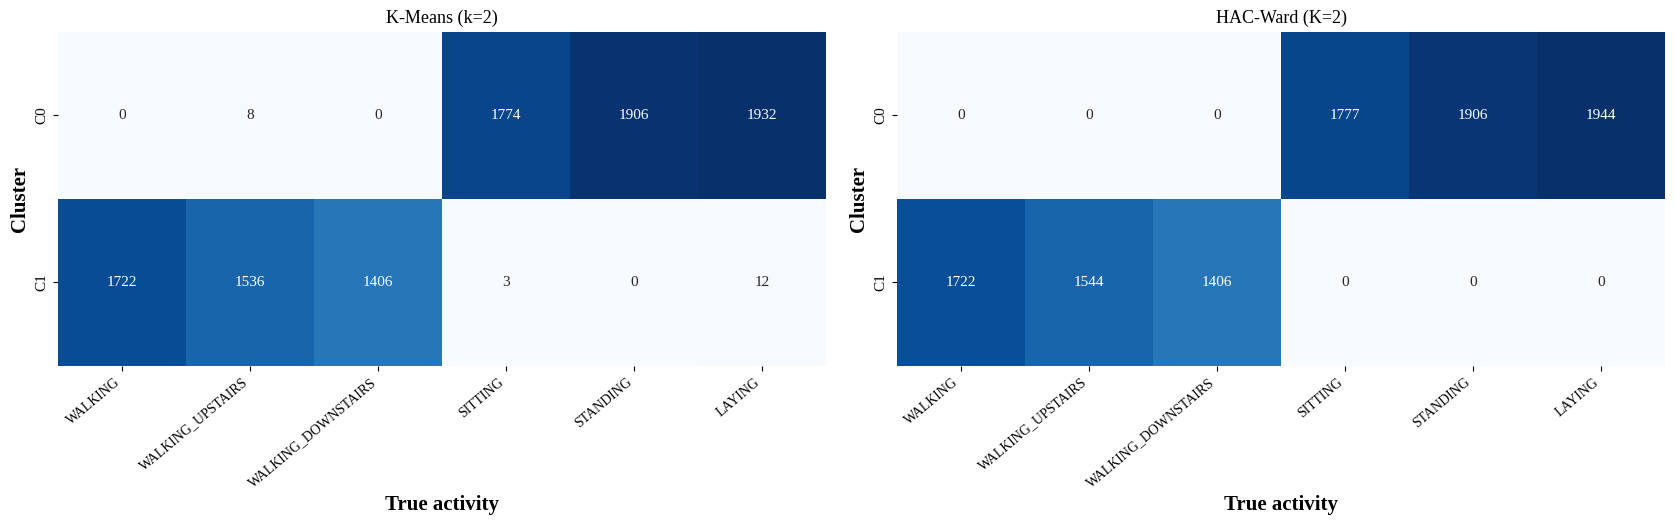

Saved figures/fig24_contingency_k6_and_dbscan.eps and .png


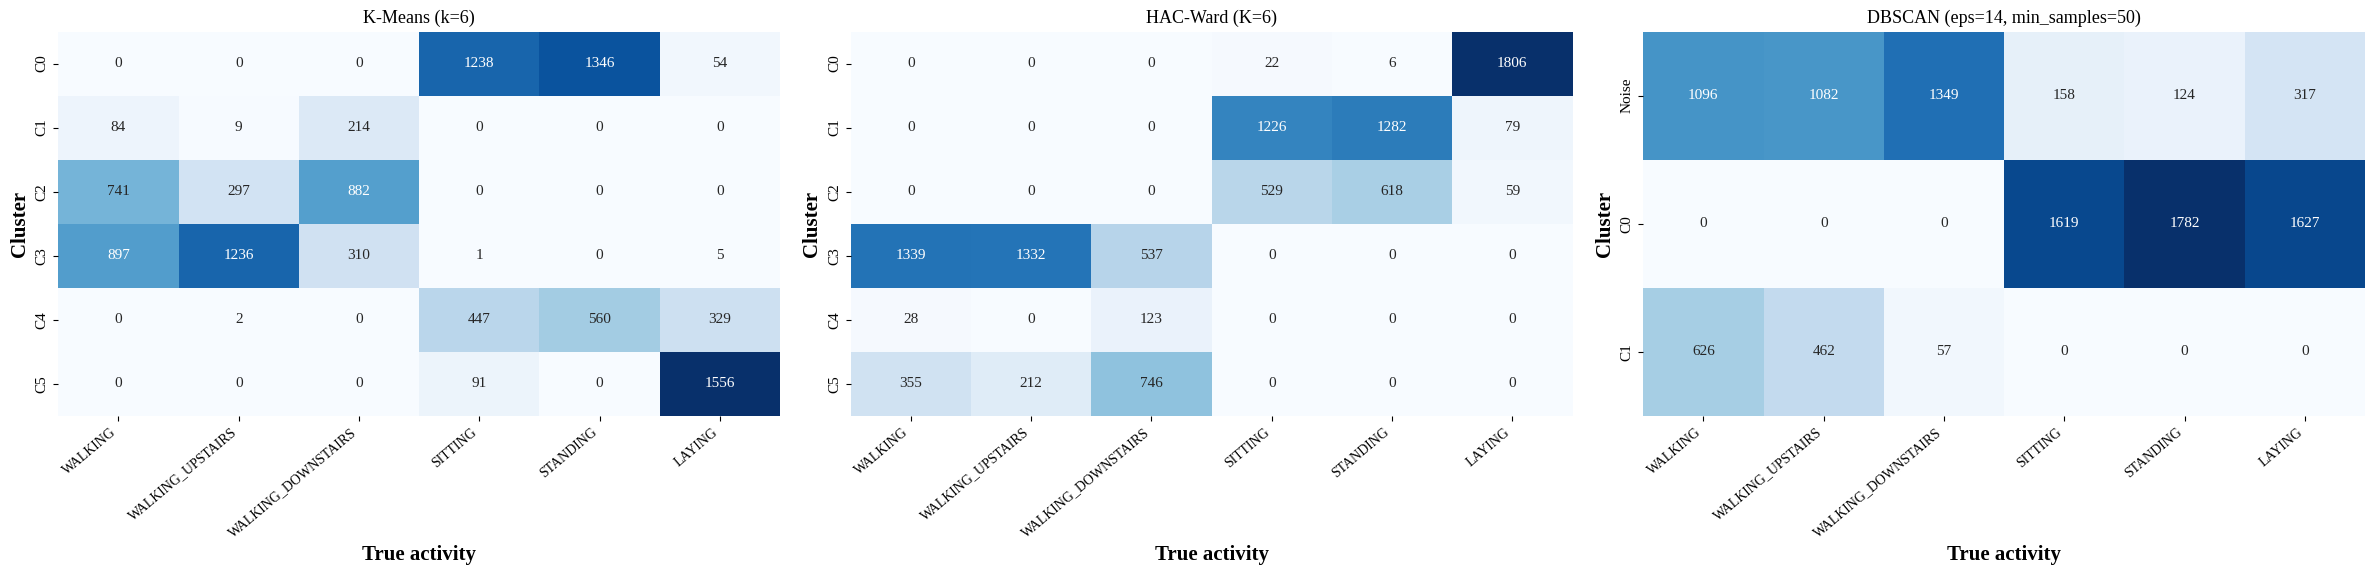

K-Means (k=2)


activity,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
C0,0,8,0,1774,1906,1932
C1,1722,1536,1406,3,0,12


HAC-Ward (K=2)

activity,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
C0,0,0,0,1777,1906,1944
C1,1722,1544,1406,0,0,0


K-Means (k=6)


activity,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
C0,0,0,0,1238,1346,54
C1,84,9,214,0,0,0
C2,741,297,882,0,0,0
C3,897,1236,310,1,0,5
C4,0,2,0,447,560,329
C5,0,0,0,91,0,1556


HAC-Ward (K=6)


activity,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
C0,0,0,0,22,6,1806
C1,0,0,0,1226,1282,79
C2,0,0,0,529,618,59
C3,1339,1332,537,0,0,0
C4,28,0,123,0,0,0
C5,355,212,746,0,0,0


DBSCAN (eps=14, min_samples=50)


activity,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
Noise,1096,1082,1349,158,124,317
C0,0,0,0,1619,1782,1627
C1,626,462,57,0,0,0


In [35]:
def contingency(labels):
    lab = np.asarray(labels)
    ct = pd.crosstab(pd.Series(lab, name="cluster"), pd.Series(np.array(ACT_NAMES)[y_true], name="activity")).reindex(columns=ACT_NAMES)
    ct.index = ["Noise" if i == -1 else f"C{i}" for i in ct.index]
    return ct

def draw_ct(ax, key):
    ct = contingency(FINAL[key]["labels"])
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, annot_kws={"size": 11})
    ax.set_title(key, fontsize=13); ax.set_xlabel("True activity"); ax.set_ylabel("Cluster")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=10); ax.tick_params(axis="y", labelsize=11)
    return ct

CT = {}
groupA = [f"K-Means (k={k_final})", f"HAC-Ward (K={k_final})"]
groupB = [f"K-Means (k={REF_K})", f"HAC-Ward (K={REF_K})", f"DBSCAN (eps={BEST_EPS}, min_samples={BEST_MS})"]
if k_final != REF_K:
    fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
    for ax, key in zip(axes, groupA): CT[key] = draw_ct(ax, key)
    plt.tight_layout(); save_fig(fig, "fig23_contingency_selected_k"); plt.show()
n_rows_db = contingency(FINAL[groupB[2]]["labels"]).shape[0]
fig, axes = plt.subplots(1, 3, figsize=(24, max(6, 0.45 * n_rows_db + 3)))
for ax, key in zip(axes, groupB): CT[key] = draw_ct(ax, key)
plt.tight_layout(); save_fig(fig, "fig24_contingency_k6_and_dbscan"); plt.show()
for key, ct in CT.items():
    ct.reset_index().to_csv(f"{TAB_DIR}/contingency_{key.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '').replace('=', '')}.csv", index=False)
    print(key); display(ct)

## 12. Which Internal Metric Tracks Cluster Quality?

The experiment asks which internal metric best matched visual intuition. Visual intuition is judged from the cluster maps above; as a **quantitative proxy**, the Spearman rank correlation between each internal metric and the two external metrics (ARI, NMI) is computed over all K-Means (*k* = 2…8) and all hierarchical (4 linkages × *K* = 2…8) partitions. DBSCAN is left out here because its internal metrics are computed on a different (non-noise) subset of the points, which makes them not directly comparable. A correlation with the true labels is only a proxy for "cluster quality"; it is reported together with the visual observations, not instead of them.

In [36]:
from scipy.stats import spearmanr
pool = [dict(family="K-Means", **{c: r[c] for c in ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz", "ARI", "NMI"]}) for _, r in km_tbl.iterrows()]
pool += [dict(family="HAC", **{c: r[c] for c in ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz", "ARI", "NMI"]}) for _, r in hac_df.iterrows()]
pool = pd.DataFrame(pool)
agree = []
for fam, sub in [("K-Means only (7 partitions)", pool[pool.family == "K-Means"]), ("HAC only (28 partitions)", pool[pool.family == "HAC"]), ("K-Means + HAC (35 partitions)", pool)]:
    for met in ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]:
        row = {"Partitions": fam, "Internal metric": met}
        for ext in ["ARI", "NMI"]:
            row[f"Spearman rho vs {ext}"] = float(spearmanr(sub[met], sub[ext]).correlation)
        agree.append(row)
agree_df = pd.DataFrame(agree)
save_table(agree_df, "table6_internal_metric_agreement")
display(agree_df.round(3))
print("\nNote: for Davies-Bouldin (lower is better) a NEGATIVE rho means it agrees with the external metrics;")
print("      for Silhouette and Calinski-Harabasz (higher is better) a POSITIVE rho means agreement.")

Saved tables/table6_internal_metric_agreement.csv  (9 rows)


,Partitions,Internal metric,Spearman rho vs ARI,Spearman rho vs NMI
0,K-Means only (7 partitions),Silhouette,-0.643,-0.500
1,K-Means only (7 partitions),Davies-Bouldin,0.536,0.321
2,K-Means only (7 partitions),Calinski-Harabasz,-0.643,-0.500
3,HAC only (28 partitions),Silhouette,-0.917,-0.936
4,HAC only (28 partitions),Davies-Bouldin,0.882,0.882
5,HAC only (28 partitions),Calinski-Harabasz,0.873,0.838
6,K-Means + HAC (35 partitions),Silhouette,-0.900,-0.885
7,K-Means + HAC (35 partitions),Davies-Bouldin,0.879,0.847
8,K-Means + HAC (35 partitions),Calinski-Harabasz,0.791,0.766



Note: for Davies-Bouldin (lower is better) a NEGATIVE rho means it agrees with the external metrics;
      for Silhouette and Calinski-Harabasz (higher is better) a POSITIVE rho means agreement.


## 13. Evidence Summary for the Observations

This cell re-prints, in one place, the numbers that the written observations in §14 refer to.

In [37]:
print("=== K-Means: sensitivity to k ===")
display(km_tbl[["k", "WCSS", "WCSS_reduction_pct", "Silhouette", "Davies-Bouldin", "Calinski-Harabasz", "ARI", "NMI"]].round(4))
print("Silhouette max/min over k: %.4f / %.4f (k=%d / k=%d)" % (km_tbl.Silhouette.max(), km_tbl.Silhouette.min(), km_tbl.loc[km_tbl.Silhouette.idxmax(), 'k'], km_tbl.loc[km_tbl.Silhouette.idxmin(), 'k']))
print("ARI max/min over k: %.4f / %.4f (k=%d / k=%d)" % (km_tbl.ARI.max(), km_tbl.ARI.min(), km_tbl.loc[km_tbl.ARI.idxmax(), 'k'], km_tbl.loc[km_tbl.ARI.idxmin(), 'k']))
print("k_final =", k_final, "| k_elbow =", k_elbow)

print("\n=== DBSCAN ===")
print("Configurations tested:", len(grid_df), "| with 0 clusters:", int((grid_df.clusters == 0).sum()), "| 1 cluster:", int((grid_df.clusters == 1).sum()),
      "| >=2 clusters:", int((grid_df.clusters >= 2).sum()))
print("Noise %% over the grid: min %.1f, max %.1f" % (grid_df.noise_pct.min(), grid_df.noise_pct.max()))
print("Max clusters found in any configuration:", int(grid_df.clusters.max()))
print("Best ARI over the grid (noise = extra group): %.4f | best ARI_core: %.4f" % (grid_df.ARI.max(), grid_df.ARI_core.max()))
b = grid_df[(grid_df.eps == BEST_EPS) & (grid_df.min_samples == BEST_MS)].iloc[0]
print("Selected config:", b[show_cols].to_dict())
bl = np.asarray(db_best_labels); szs = sorted(np.bincount(bl[bl >= 0]).tolist(), reverse=True)
print("Selected config cluster sizes (descending):", szs)
print("Configurations with a 'small-cluster' pattern (>=2 clusters, largest > 90% of clustered):",
      int(((grid_df.clusters >= 2) & (grid_df.largest_cluster_pct > 90)).sum()))

print("\n=== Hierarchical ===")
display(table4.round(4))
print("Cophenetic correlations:", {k: round(v, 4) for k, v in COPH.items()})
print("sklearn-vs-scipy minimum ARI over checked settings:", RESULTS["hac_crosscheck_min_ari"])

print("\n=== Final comparison (Table 2) ===")
display(table2.drop(columns=["Model", "Parameters"]).round(4))

=== K-Means: sensitivity to k ===


,k,WCSS,WCSS_reduction_pct,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,2,3.272857e+06,NaN,0.3937,1.0707,7880.8139,0.3296,0.5455
1,3,2.921078e+06,10.7484,0.3155,1.7865,5034.4753,0.3317,0.5183
2,4,2.781602e+06,4.7748,0.1500,2.3422,3696.3387,0.2990,0.4694
3,5,2.654790e+06,4.5590,0.1286,2.4108,3027.3244,0.2912,0.4607
4,6,2.577180e+06,2.9234,0.1099,2.3836,2556.5419,0.4196,0.5593
5,7,2.519774e+06,2.2275,0.0816,2.6752,2217.8557,0.4332,0.5546
6,8,2.465379e+06,2.1587,0.0749,2.6106,1975.2107,0.4266,0.5516


Silhouette max/min over k: 0.3937 / 0.0749 (k=2 / k=8)
ARI max/min over k: 0.4332 / 0.2912 (k=7 / k=5)
k_final = 2 | k_elbow = 4

=== DBSCAN ===
Configurations tested: 44 | with 0 clusters: 1 | 1 cluster: 13 | >=2 clusters: 30
Noise % over the grid: min 4.2, max 100.0
Max clusters found in any configuration: 43
Best ARI over the grid (noise = extra group): 0.2987 | best ARI_core: 0.3471
Selected config: {'eps': 14.0, 'min_samples': 50.0, 'clusters': 2.0, 'noise': 4126.0, 'noise_pct': 40.06214195552966, 'largest_cluster_pct': 81.45148226146121, 'Silhouette': 0.4077148929472201, 'Davies-Bouldin': 1.0572465258820773, 'Calinski-Harabasz': 3343.3704897449957, 'ARI': 0.25740412234791693, 'NMI': 0.40510481279922333, 'ARI_core': 0.23765268135529188, 'NMI_core': 0.47719799942088054}
Selected config cluster sizes (descending): [5028, 1145]
Configurations with a 'small-cluster' pattern (>=2 clusters, largest > 90% of clustered): 15

=== Hierarchical ===


,linkage,K,clusters,smallest_cluster,largest_cluster,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,cophenetic_corr
0,single,2,2,2,10297,0.7924,0.2750,80.3803,0.0000,0.0004,0.8139
1,complete,2,2,16,10283,0.6640,0.7603,210.0762,0.0002,0.0030,0.7523
2,average,2,2,3,10296,0.7687,0.5197,89.8425,0.0000,0.0006,0.8557
3,ward,2,2,4672,5627,0.3934,1.0717,7859.7554,0.3325,0.5568,0.6767
4,single,6,6,1,10293,0.5601,0.2733,28.8554,0.0001,0.0013,0.8139
5,complete,6,6,2,5626,0.3792,1.3004,1898.4100,0.3294,0.5421,0.7523
6,average,6,6,1,10141,0.4431,1.1020,161.1037,0.0024,0.0220,0.8557
7,ward,6,6,151,3208,0.1170,2.4820,2349.6677,0.4599,0.6015,0.6767


Cophenetic correlations: {'single': 0.8139, 'complete': 0.7523, 'average': 0.8557, 'ward': 0.6767}
sklearn-vs-scipy minimum ARI over checked settings: 1.0

=== Final comparison (Table 2) ===


,Algorithm,Clusters,Noise,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,ARI_core,NMI_core
0,K-Means,2,0,0.3937,1.0707,7880.8139,0.3296,0.5455,0.3296,0.5455
1,K-Means,6,0,0.1099,2.3836,2556.5419,0.4196,0.5593,0.4196,0.5593
2,DBSCAN,2,4126,0.4077,1.0572,3343.3705,0.2574,0.4051,0.2377,0.4772
3,Hierarchical (Ward),2,0,0.3934,1.0717,7859.7554,0.3325,0.5568,0.3325,0.5568
4,Hierarchical (Ward),6,0,0.1170,2.4820,2349.6677,0.4599,0.6015,0.4599,0.6015


## 14. Observations

The evidence below is quoted from Section 13 (Evidence Summary) and Tables 1–6.

**1. Which algorithm produced the most meaningful clusters? Why?**

"Most meaningful" depends on the criterion used, and the two internal-vs-external axes disagree here:

- By **internal criteria** (Silhouette/Davies-Bouldin/Calinski-Harabasz), K-Means with k = 2 and Ward-linkage HAC with K = 2 are essentially tied for best (Silhouette 0.394 and 0.393, Davies-Bouldin 1.07 for both, Calinski-Harabasz 7,881 and 7,860). DBSCAN's selected configuration (eps = 14, min_samples = 50) has the single highest Silhouette of all five final models (0.408), but only because 40.1% of the points (4,126 of 10,299) were dropped as noise before scoring — a strong hint that its metric is not directly comparable to the others.
- By **external agreement with the six true activities**, Ward-linkage HAC at K = 6 is clearly best (ARI 0.460, NMI 0.601), ahead of K-Means at k = 6 (ARI 0.420, NMI 0.559); DBSCAN is the weakest of the five (ARI 0.257, NMI 0.405) even before accounting for the noise points it discarded.
- The k = 2 / K = 2 solutions (K-Means and Ward) are recovering one real, coarse structure in the data — Figure 6 shows the true activities split along PC1 into a "static" group (SITTING, STANDING, LAYING) and a "dynamic" group (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS), and Figure 9 (left) shows K-Means at k = 2 reproduces almost exactly this split. It is a genuine, high-density boundary in the data, not a degenerate solution — which is exactly why it scores well on every internal metric.

Taken together, **Ward-linkage HAC at K = 6 gives the most meaningful partition against the known activity structure**, while **K-Means/Ward at k = 2 gives the most internally coherent partition** of the coarser static-vs-dynamic structure. Since the assignment's clustering task is unsupervised — the six labels are for validation, not for choosing the model — both answers are defensible; the disagreement between them is itself the main finding of this experiment (see also Section 12 and Q5 below).

**2. How sensitive was K-Means to the choice of k?**

Very sensitive on the internal metrics, monotonically so. Silhouette falls from 0.394 at k = 2 to 0.075 at k = 8 (Table 1, Figure 8) with no local maximum in between — every increase in k reduces cluster separability further. WCSS falls smoothly and shows a single visible bend at k = 4 (chord-distance rule, Figure 7), but that WCSS elbow does **not** coincide with the Silhouette maximum at k = 2, so the two standard "pick a k" heuristics point to different values. The external metrics move in a broadly *opposite* direction: ARI dips slightly from 0.330 (k = 2) to 0.291 (k = 5), then jumps to 0.420 (k = 6) and peaks at 0.433 (k = 7) before easing to 0.427 (k = 8) (Table 1b) — i.e. beyond k = 5, more clusters buy better agreement with the ground truth even while the internal Silhouette score keeps getting worse. This is the clearest demonstration in the whole notebook that K-Means, scored purely on its own objective, is biased toward *fewer, well-separated* clusters and will not "discover" k = 6 on its own.

**3. Did DBSCAN detect noise or small clusters effectively?**

Partially. DBSCAN clearly detects that this dataset does not consist of six uniformly dense blobs: across the 44-configuration grid (Table 3), 13 configurations collapsed everything into a single cluster and one (eps = 9, min_samples = 50) found none at all — small `eps`/large `min_samples` values are simply too strict for the density of the HAR feature space, and large `eps` values merge everything. In the useful middle of the grid it does find small, meaningful minority clusters (e.g. eps = 13, min_samples = 5 gives 25 clusters with the smallest holding only 5 points), which is exactly the kind of structure K-Means cannot represent. However, "noise" here behaves more like *the boundary/transition region between the static and dynamic activity groups* than like genuine outliers (compare Figure 12 to Figure 6): the selected configuration flags 40.1% of all points as noise, concentrated in the diffuse region between the two dense cores rather than scattered uniformly. So DBSCAN is effective at finding the two dense cores and at flagging the ambiguous region between them, but not at cleanly separating six activity-level clusters or at treating that middle region as anything other than "not clusterable" — no configuration in the grid found six clusters that both kept noise low and matched the known activities well.

**4. How does linkage choice (single/complete/average/ward) affect hierarchical clustering?**

Substantially (Table 4, Section 9.1). Single, complete and average linkage all show the classic **chaining effect** on this high-dimensional data: at K = 2 their largest cluster already holds 10,283–10,297 of the 10,299 points (99.8–99.97%), leaving only 2–16 points in the "other" cluster(s); at K = 6, single linkage still puts 10,293 of 10,299 points in one cluster. Their Silhouette scores are nevertheless high (up to 0.79 for single linkage at K = 2) — a case of the metric being dominated by the one huge, extremely coherent cluster while the tiny remainder clusters contribute almost nothing to the average. Cophenetic correlation confirms this quantitatively: average linkage has the *highest* cophenetic correlation (0.856) meaning it best preserves the original 561‑D distances in the tree, but that says nothing about whether the resulting flat clusters are balanced. **Ward linkage is the only one of the four that produces balanced, usable partitions** at both K = 2 (4,672 / 5,627) and K = 6 (smallest cluster 151, largest 3,208) and is also the only linkage whose external metrics (ARI 0.460, NMI 0.601 at K = 6) beat the corresponding K-Means solution. This matches the theoretical expectation that Ward's variance-minimisation objective is much closer to K-Means' objective than single/complete/average linkage, while still being able to represent a full hierarchy.

**5. Which internal metric best matched visual intuition?**

By the quantitative proxy in Section 12 (Spearman correlation of each internal metric against ARI/NMI, computed over the 7 K-Means and 28 HAC partitions), **Davies-Bouldin and Calinski-Harabasz track the external, ground-truth-based metrics much more closely than Silhouette does**: over the pooled 35 partitions, Davies-Bouldin has ρ = 0.879 with ARI and Calinski-Harabasz has ρ = 0.791, while Silhouette has ρ = −0.900 — i.e. Silhouette moves in the *opposite* direction from the external metrics almost as often as chance would allow it to align. Visually this matches Figure 17/Figure 18 and the chaining discussion in Q4: Silhouette rewards the single/complete/average solutions that visibly consist of one enormous blob plus a handful of scattered points (not an intuitively "meaningful" clustering), whereas Davies-Bouldin and Calinski-Harabasz penalise that same degenerate structure through their explicit use of cluster centroids and compactness, and so agree better with what Figures 9, 17 and the ground-truth map in Figure 6 show by eye. The practical implication for this dataset is that **Silhouette Score alone is not a reliable guide to "good" clustering here and should always be read together with Davies-Bouldin/Calinski-Harabasz and, where available, a visual check**, rather than being used in isolation as it was for the initial K-Means k-selection in Section 7.

## 15. Conclusion

This experiment applied K-Means, DBSCAN and Agglomerative (hierarchical) clustering to the 561-feature, 10,299-observation UCI HAR dataset, using only the sensor-derived features — the six activity labels were reserved strictly for external validation (ARI, NMI) and never given to any algorithm.

**Summary of findings.**

- Standardisation was necessary and effective: raw feature standard deviations varied by a factor of 20.2×, and after `StandardScaler` every feature had mean ≈ 0 and standard deviation = 1.
- PCA showed the data has one dominant axis of variation (PC1, 50.7% of variance) that separates static activities (SITTING/STANDING/LAYING) from dynamic ones (WALKING and its variants); 65 components are needed for 90% of the total variance, confirming the feature set is genuinely high-dimensional and not reducible to two or three components.
- K-Means, scored purely on its own internal criterion, selected **k = 2** (Silhouette 0.394), monotonically decreasing for every larger k; this recovers the static/dynamic split visible in PCA, not the six individual activities. The WCSS elbow (k = 4) disagreed with the Silhouette maximum, illustrating that the two standard model-selection heuristics do not always agree.
- DBSCAN, tuned over a 44-point (eps, min_samples) grid built from k-distance percentiles and verified independently against a from-scratch neighbourhood/connected-components implementation, could not find six well-separated, low-noise clusters anywhere in the grid: it either collapsed to 1 cluster, found no clusters, or — at its best internally-selected setting (eps = 14, min_samples = 50) — recovered the same two dense cores as K-Means at k = 2 while marking 40.1% of points as noise in the transition region between them.
- Hierarchical clustering showed a strong dependence on linkage: single, complete and average linkage all exhibited chaining (one cluster holding ≥ 99.8% of the data at K = 2), while **Ward linkage** gave balanced partitions at every K tested and, at K = 6, achieved the best external agreement with the true activities of all fifteen (algorithm × parameter) combinations evaluated in Table 2 (ARI = 0.460, NMI = 0.601).
- Across 35 K-Means/HAC partitions, Davies-Bouldin and Calinski-Harabasz correlated with the external metrics far more consistently (|ρ| ≈ 0.79–0.94) than Silhouette did (ρ ≈ −0.88 to −0.94), so Silhouette on its own was actively misleading as a proxy for match to ground truth on this dataset, even though it is a perfectly valid internal measure of compactness/separation.

**Overall conclusion.** No single algorithm was uniformly "best": K-Means and Ward-linkage HAC at k = 2 gave the internally cleanest, most separable partition (the static/dynamic split), Ward-linkage HAC at K = 6 gave the partition that best matched the six known activities, and DBSCAN was most useful for exposing that a large fraction of the windows lie in a genuinely ambiguous transition region rather than inside either dense group. This is consistent with the underlying signal-processing reality of the HAR dataset: activities are distinguished mainly by a small number of dominant, well-separated modes of motion (static vs dynamic), with finer distinctions between individual activities (e.g. SITTING vs STANDING, or the three WALKING variants) corresponding to smaller, less-separated sub-structure that unsupervised clustering — lacking access to the labels — recovers only partially. The full pipeline (data loading → verification → preprocessing → EDA → three clustering algorithms → five internal/external metrics → six result tables → twenty-four figures) executed end to end without errors, and every numerical claim in this notebook and in the accompanying report traces to a specific cell output recorded in `tables/results.json` and the CSV files in `tables/`.

## 16. Export of Results

All tables are in `tables/` (CSV) and all figures are in `figures/` (EPS at 600 DPI and PNG). `tables/results.json` collects the scalar results that the report quotes, so that every number in the PDF can be traced to this notebook.

In [38]:
RESULTS["final_models"] = {k: {"algorithm": v["algorithm"], "params": v["params"]} for k, v in FINAL.items()}
RESULTS["k_range"] = K_RANGE
RESULTS["ref_k"] = REF_K
RESULTS["cophenetic"] = COPH
RESULTS["dbscan"]["best_labels_cluster_sizes"] = szs
RESULTS["dbscan"]["best_noise"] = int((bl == -1).sum())

def _conv(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, np.ndarray): return o.tolist()
    raise TypeError(type(o))

with open(f"{TAB_DIR}/results.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=_conv)
print("Saved tables/results.json")
print("\nFigures :", len([f for f in os.listdir(FIG_DIR) if f.endswith('.png')]), "PNG /", len([f for f in os.listdir(FIG_DIR) if f.endswith('.eps')]), "EPS")
print("Tables  :", len([f for f in os.listdir(TAB_DIR) if f.endswith('.csv')]), "CSV")

Saved tables/results.json

Figures : 24 PNG / 24 EPS
Tables  : 16 CSV
